# Non-heartbeat message alignment — multi-session

Sister notebook to `check_nonheart_messages.ipynb`. Same scoring (per-pair `pearson`, `err_std_before`, `mean_interval`, `coverage`, etc.), but runs across every session in `heartbeat/sess_missing_heartbeats.csv` whose task-side `get_heart()` failed with `ValueError: No HEARTBEAT / HEARTBEAT_OK events logged!` — i.e. sessions where `session.json(l)` exists with task events but no HEARTBEATs.

Goal: identify a **(task_type, host_type) pair that works across many sessions** as a candidate anchor stream for a real (non-synthetic) `time_task ↔ time_host` regression. The ranking aggregates per-session pair stats by `n_sessions` (in how many sessions does this pair qualify), then median `pearson`, median `err_std_before`, etc.

In [26]:
%load_ext autoreload
%autoreload 2

import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmlreaders as cml

# Heartbeat helpers — co-located in the same heartbeat/ folder as this
# notebook, so no sys.path insert needed.
from fix_heartbeats_sys4 import (
    get_heart,
    prepare_merged_heartbeats,
    fit_correction,
    correct_event_times,
)

import check_nonheart as cnh


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Heartbeat Sessions

Pull the table of sessions known to be missing or broken on the heartbeat side. For each, load the raw task-laptop and host-PC logs so the alignment search has the timestamp streams it needs.

In [27]:
# Load the missing-heartbeats CSV and identify two subsets:
#  - `broken`     : task HEARTBEATs were never logged but host heartbeats
#                   exist. These are the non-heart-method's target sessions
#                   in the sister notebook.
#  - `failed_keys`: every session in `missing` (regardless of failure
#                   mode) — these CANNOT serve as ground truth because at
#                   least one side's heartbeats didn't load.
#
# `qualifying` = sessions in the same experiments minus all failed_keys =
# the set with BOTH task and host heartbeats successfully loaded (i.e.,
# usable as heartbeat-based ground truth).

missing = pd.read_csv('results/sess_missing_heartbeats.csv')
no_hb_msg = 'ValueError: No HEARTBEAT / HEARTBEAT_OK events logged!'
broken = missing[
    (missing['missing_task_laptop'] == True) &
    (missing['missing_host_pc']    == False) &
    (missing['task_error']         == no_hb_msg)
].reset_index(drop=True)

exps_of_interest = sorted(["RepFR2"])
# sorted(broken['experiment'].unique())
print(f'Experiments of interest ({len(exps_of_interest)}): {exps_of_interest}')

data = cml.get_data_index('r1').query(
    'system_version == 4 and experiment in @exps_of_interest'
).reset_index(drop=True)

# Exclude EVERY session in `missing` -- not just the broken subset.
# Sessions with FileNotFoundError on task and/or host logs are also in
# `missing` and must be excluded so we don't try to load heartbeats that
# physically aren't on disk.
failed_keys = set(zip(missing['subject'], missing['experiment'], missing['session']))
qualifying = data[~data.apply(
    lambda r: (r['subject'], r['experiment'], r['session']) in failed_keys, axis=1
)].reset_index(drop=True)

n_failed_in_exps = int(missing['experiment'].isin(exps_of_interest).sum())
print(f'\nTotal CML sessions in these experiments: {len(data)}')
print(f'  any heartbeat-load failure (excluded): {n_failed_in_exps}')
print(f'    of which broken (no task HEARTBEAT): {len(broken)}')
print(f'Qualifying (both heartbeats load):       {len(qualifying)}')
print('\nQualifying sessions per experiment:')
print(qualifying.experiment.value_counts())


Experiments of interest (1): ['RepFR2']

Total CML sessions in these experiments: 86
  any heartbeat-load failure (excluded): 1
    of which broken (no task HEARTBEAT): 172
Qualifying (both heartbeats load):       85

Qualifying sessions per experiment:
experiment
RepFR2    85
Name: count, dtype: int64


In [28]:
# Load task + host heartbeats per non-broken session, mirroring
# check_all_heartbeats.ipynb CELL 1. Output:
#   heartbeats          : DataFrame of all loaded raw heartbeats
#   prepared_by_sess    : {(sub, exp, sess, orig_sess) -> {merged_df, prep_err,
#                                                          n_task, n_host,
#                                                          samplerate}}
#   samplerates_by_sess : {(sub, exp, sess) -> samplerate} for sessions whose
#                         EEG metadata loaded successfully.
# Each merged_df is filtered to HBs whose one-way latency (task_RT / 2) is
# <= MAX_ONE_WAY_MS, so the downstream OLS GT fit only sees heartbeats at
# or below the ~1 ms network floor.

MAX_ONE_WAY_MS    = 1.0
MIN_GT_HEARTBEATS = 20

def filter_merged_one_way(df_both):
    """Merge task + host heartbeats on `count` and keep pairs whose one-way
    network latency (latency_task / 2) is <= MAX_ONE_WAY_MS. Returns
    merged_df with an extra 'one_way_latency_ms' column."""
    task = df_both[df_both['hardware_system'] == 'task_laptop']
    host = df_both[df_both['hardware_system'] == 'host_pc']
    m = pd.merge(task, host, on='count', suffixes=('_task', '_host'))
    m = m.dropna(subset=['latency_task', 'latency_host'])
    m['one_way_latency_ms'] = m['latency_task'].astype(float) / 2.0
    keep = m['one_way_latency_ms'] <= MAX_ONE_WAY_MS
    return m[keep].reset_index(drop=True)

drop_network_test = True
heartbeats_list = []
prepared_by_sess = {}

for idx, row in qualifying.iterrows():
    print('-' * 96)
    print(f'{row.subject}, {row.experiment}, session {row.session}')
    sess = None
    hb_task = None
    hb_host = None
    samplerate_sess = float('nan')
    try:
        r = cml.CMLReader(subject=row.subject, experiment=row.experiment,
                          session=row.session, localization=row.localization,
                          montage=row.montage)
        evs = r.load('events')
        # Metadata-only EEG load (1-sample window) so we get .samplerate
        # without dragging the full timeseries off disk.
        try:
            eeg = r.load_eeg(events=evs.iloc[:1], rel_start=0, rel_stop=1)
            samplerate_sess = float(eeg.samplerate)
        except Exception as e:
            print(f'  load_eeg samplerate failed: {type(e).__name__}: {e}')
        sess = (row.original_session
                if not row.isna().original_session else row.session)

        try:
            hb_task = get_heart(row.subject_alias, row.experiment, sess,
                                drop_network_test=drop_network_test,
                                load_host_pc=False, verbose=False)
            hb_task['original_session'] = hb_task.session
            hb_task.loc[:, ['session']] = row.session
            heartbeats_list.append(hb_task)
        except Exception as e:
            print(f'  task_laptop get_heart failed: {type(e).__name__}: {e}')

        try:
            hb_host = get_heart(row.subject_alias, row.experiment, sess,
                                drop_network_test=drop_network_test,
                                load_host_pc=True, verbose=False)
            hb_host['original_session'] = hb_host.session
            hb_host.loc[:, ['session']] = row.session
            heartbeats_list.append(hb_host)
        except Exception as e:
            print(f'  host_pc get_heart failed: {type(e).__name__}: {e}')
    except Exception as e:
        print(f'Error on {row.subject_alias}, {row.experiment}, '
              f'session {sess}: {e}')
        continue

    merged_df = None
    prep_err = None
    if hb_task is not None and hb_host is not None:
        try:
            merged_df = filter_merged_one_way(
                pd.concat([hb_task, hb_host], ignore_index=True))
            if len(merged_df) < MIN_GT_HEARTBEATS:
                prep_err = (f'only {len(merged_df)} HBs survive one-way filter '
                            f'(<= {MAX_ONE_WAY_MS} ms; '
                            f'< MIN_GT_HEARTBEATS={MIN_GT_HEARTBEATS}) - '
                            f'skipping GT correction')
                merged_df = None
        except Exception as e:
            prep_err = f'filter failed: {type(e).__name__}: {e}'
    elif hb_task is None and hb_host is not None:
        prep_err = 'task-laptop heartbeats missing - skipping correction'
    elif hb_host is None:
        prep_err = 'host heartbeats missing - skipping correction'
    else:
        prep_err = 'no heartbeats loaded'

    prepared_by_sess[(row.subject, row.experiment, row.session, sess)] = {
        'merged_df':  merged_df,
        'prep_err':   prep_err,
        'n_task':     0 if hb_task is None else len(hb_task),
        'n_host':     0 if hb_host is None else len(hb_host),
        'samplerate': samplerate_sess,
    }

heartbeats = (pd.concat(heartbeats_list, ignore_index=True)
              if heartbeats_list else pd.DataFrame())

samplerates_by_sess = {
    (sub, exp, sess): v['samplerate']
    for (sub, exp, sess, _), v in prepared_by_sess.items()
    if not pd.isna(v.get('samplerate', float('nan')))
}

n_with_merged = sum(1 for v in prepared_by_sess.values()
                    if v['merged_df'] is not None)
print(f'\nsessions with usable merged_df: {n_with_merged} / {len(prepared_by_sess)}')
print(f'one-way latency filter: <= {MAX_ONE_WAY_MS} ms  '
      f'(min HBs after filter: {MIN_GT_HEARTBEATS})')
print(f'samplerates: {len(samplerates_by_sess)} / {len(prepared_by_sess)} sessions  '
      f'(unique values: {sorted(set(samplerates_by_sess.values()))})')
heartbeats.head(1000)


------------------------------------------------------------------------------------------------
R1556J, RepFR2, session 0


/home1/zrentala/bids-convert/heartbeat/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


------------------------------------------------------------------------------------------------
R1579T, RepFR2, session 0


/home1/zrentala/bids-convert/heartbeat/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


------------------------------------------------------------------------------------------------
R1585E, RepFR2, session 0


...

/home1/zrentala/bids-convert/heartbeat/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


------------------------------------------------------------------------------------------------
R1724J, RepFR2, session 1


/home1/zrentala/bids-convert/heartbeat/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)



sessions with usable merged_df: 85 / 85
one-way latency filter: <= 1.0 ms  (min HBs after filter: 20)
samplerates: 83 / 85 sessions  (unique values: [1000.0])


,subject,experiment,session,original_session,hardware_system,count,time,time_HEARTBEAT_OK,latency,id
0,R1556J_1,RepFR2,0,0,task_laptop,21,1.451616e+12,1.451616e+12,1.010010,110.0
1,R1556J_1,RepFR2,0,0,task_laptop,22,1.451616e+12,1.451616e+12,1.030029,114.0
2,R1556J_1,RepFR2,0,0,task_laptop,23,1.451616e+12,1.451616e+12,0.939941,118.0
3,R1556J_1,RepFR2,0,0,task_laptop,24,1.451616e+12,1.451616e+12,0.959961,122.0
4,R1556J_1,RepFR2,0,0,task_laptop,25,1.451616e+12,1.451616e+12,0.810059,126.0
...,...,...,...,...,...,...,...,...,...,...
995,R1556J_1,RepFR2,0,0,task_laptop,1016,1.451617e+12,1.451617e+12,1.840088,6376.0
996,R1556J_1,RepFR2,0,0,task_laptop,1017,1.451617e+12,1.451617e+12,1.209961,6380.0
997,R1556J_1,RepFR2,0,0,task_laptop,1018,1.451617e+12,1.451617e+12,1.500000,6384.0
998,R1556J_1,RepFR2,0,0,task_laptop,1019,1.451617e+12,1.451617e+12,1.369873,6388.0


# Score Sessions

Run all-pair scoring on every qualifying session: for each `(task_type, host_type)` combination compute Pearson correlation, residual std, event counts, and coverage. Output is one row per `(session, pair)`.

In [29]:
# Run scoring across all qualifying sessions.
all_pairs_df, session_event_cache, skipped = cnh.score_all_sessions(qualifying, verbose=False)

## Sort Candidates By Pearson Correlation and Number of Messages

Aggregate per-session scores up to one row per `(experiment, task_type, host_type)` candidate, ranked by median Pearson. Inspect the top performers globally and per experiment.

In [30]:
# Aggregate per (task_type, host_type) across all sessions.
agg = cnh.aggregate_pairs(all_pairs_df)
if not agg.empty:
    n_sessions_total = all_pairs_df[['subject', 'experiment', 'session']] \
        .drop_duplicates().shape[0]
    print(f'unique (task_type, host_type) pairs across {n_sessions_total} sessions: {len(agg)}')
    print(f'pearson_bucket precision: {cnh.PEARSON_TOL} '
          f'({cnh.PEARSON_ROUND} decimals - pearsons within this are treated as tied)')
    print()
    display(agg)
    # print('Top 25 candidates:')
    # display(agg.head(25))


unique (task_type, host_type) pairs across 84 sessions: 47
pearson_bucket precision: 1e-05 (5 decimals - pearsons within this are treated as tied)



,task_type,host_type,match_type,n_sessions,median_pearson,median_n_pairs,median_err_std_before,median_err_mean_before,median_mean_interval,median_cv_burst,median_coverage,max_err_std_before,session_frac,pearson_bucket
0,END RECALL PERIOD,TRIALEND,cross_name,83,1.000000,21.0,1.631858,1.789348e+05,96780.235828,0.040474,0.893580,32.956550,0.988095,1.00000
1,START RECALL PERIOD,RECALL,cross_name,83,1.000000,21.0,2.464404,1.789361e+05,96779.876648,0.040458,0.893561,33.287484,0.988095,1.00000
2,END RECALL PERIOD,RECALL,cross_name,83,1.000000,21.0,11.994521,1.487309e+05,96779.876648,0.040458,0.893561,44.005829,0.988095,1.00000
3,START RECALL PERIOD,TRIALEND,cross_name,83,1.000000,21.0,12.894056,2.091401e+05,96780.235828,0.040474,0.893580,49.195040,0.988095,1.00000
4,DISPLAY RECALL TEXT,COUNTDOWN,cross_name,83,1.000000,21.0,355.074119,1.237524e+05,96774.076953,0.040022,0.893825,549.959299,0.988095,1.00000
5,TRIALEND,TRIALEND,same_name,82,1.000000,21.0,1.549881,1.756989e+05,96737.908252,0.040493,0.896903,32.965824,0.976190,1.00000
6,RECALL,RECALL,same_name,82,1.000000,21.0,1.566692,1.757002e+05,96736.528595,0.040506,0.896897,33.290911,0.976190,1.00000
7,WORD,WORD,same_name,82,1.000000,567.0,8.069568,1.757016e+05,3493.071496,2.780377,0.916779,31.814630,0.976190,1.00000
8,ISI,ISI,same_name,82,1.000000,588.0,8.298279,1.757016e+05,3370.902721,2.742814,0.917583,36.930162,0.976190,1.00000
9,TRIALEND,RECALL,cross_name,82,1.000000,21.0,11.902388,1.455108e+05,96736.528595,0.040506,0.896897,44.009070,0.976190,1.00000


In [31]:
# Per-experiment aggregation. Different experiments have different event
# vocabularies, so the best anchor pair is likely experiment-specific.
agg_per_exp = cnh.aggregate_pairs_per_experiment(all_pairs_df)

TOP_K = 100
if not agg_per_exp.empty:
    for exp, grp in agg_per_exp.groupby('experiment', sort=False):
        n_sess = int(grp['exp_n_sessions'].iloc[0])
        print(f'\n{"=" * 96}\n{exp}   ({n_sess} sessions, {len(grp)} unique pairs)\n{"=" * 96}')
        display(grp.drop(columns=['exp_n_sessions']).head(TOP_K).reset_index(drop=True))



RepFR2   (84 sessions, 47 unique pairs)


,experiment,task_type,host_type,match_type,n_sessions,median_pearson,median_n_pairs,median_err_std_before,median_err_mean_before,median_mean_interval,median_cv_burst,median_coverage,max_err_std_before,session_frac,pearson_bucket
0,RepFR2,END RECALL PERIOD,TRIALEND,cross_name,83,1.000000,21.0,1.631858,1.789348e+05,96780.235828,0.040474,0.893580,32.956550,0.988095,1.00000
1,RepFR2,START RECALL PERIOD,RECALL,cross_name,83,1.000000,21.0,2.464404,1.789361e+05,96779.876648,0.040458,0.893561,33.287484,0.988095,1.00000
2,RepFR2,END RECALL PERIOD,RECALL,cross_name,83,1.000000,21.0,11.994521,1.487309e+05,96779.876648,0.040458,0.893561,44.005829,0.988095,1.00000
3,RepFR2,START RECALL PERIOD,TRIALEND,cross_name,83,1.000000,21.0,12.894056,2.091401e+05,96780.235828,0.040474,0.893580,49.195040,0.988095,1.00000
4,RepFR2,DISPLAY RECALL TEXT,COUNTDOWN,cross_name,83,1.000000,21.0,355.074119,1.237524e+05,96774.076953,0.040022,0.893825,549.959299,0.988095,1.00000
5,RepFR2,TRIALEND,TRIALEND,same_name,82,1.000000,21.0,1.549881,1.756989e+05,96737.908252,0.040493,0.896903,32.965824,0.976190,1.00000
6,RepFR2,RECALL,RECALL,same_name,82,1.000000,21.0,1.566692,1.757002e+05,96736.528595,0.040506,0.896897,33.290911,0.976190,1.00000
7,RepFR2,WORD,WORD,same_name,82,1.000000,567.0,8.069568,1.757016e+05,3493.071496,2.780377,0.916779,31.814630,0.976190,1.00000
8,RepFR2,ISI,ISI,same_name,82,1.000000,588.0,8.298279,1.757016e+05,3370.902721,2.742814,0.917583,36.930162,0.976190,1.00000
9,RepFR2,TRIALEND,RECALL,cross_name,82,1.000000,21.0,11.902388,1.455108e+05,96736.528595,0.040506,0.896897,44.009070,0.976190,1.00000


## Hard-Coded Task ↔ Host Pairings

Two lists. The candidate list is a strict subset of the evaluation list:

- **`eval_pairs`** — full semantic mapping (anchors + singletons + stim). Used downstream to decide which `(task_type, host_type)` events get corrected and have residuals/drift computed.
- **`unambiguous`** — subset of `eval_pairs` that passes Pearson / event-count / session-coverage thresholds. Only these are used as **fit candidates** (anchor regressions). Drives `nh_fits` → `top_candidates`.

Singletons (READY, SESSION, CONFIGURE, CONNECTED, EXIT) are scored-but-not-fitted: they appear in `eval_pairs` so the residual builder evaluates how well the anchor fit corrects them, but they can't anchor a regression themselves (1–2 events/session).

In [32]:
# Hard-coded task ↔ host pair list. Two derived sets:
#   eval_pairs  -- everything below, used for residual / drift evaluation
#   unambiguous -- subset of eval_pairs that passes quality cuts, used as
#                  fit candidates (anchor regressions)

REPFR1_ANCHOR_PAIRS = [
    ('WORD',       'WORD'),
    ('ISI',        'ISI'),
    ('TRIAL',      'TRIAL'),
    ('TRIALEND',   'TRIALEND'),
    ('RECALL',     'RECALL'),
    # ('REST',       'REST'),
    # ('COUNTDOWN',  'COUNTDOWN'),
]

REPFR1_SINGLETON_PAIRS = [
    ('READY',      'READY'),
    ('SESSION',    'SESSION'),
    ('CONNECTED',  'CONNECTED'),
    ('CONFIGURE',  'CONFIGURE'),
    ('EXIT',       'EXIT'),
    # host has _OK acks for the handshake messages:
    # ('CONNECTED',  'CONNECTED_OK'),
    # ('CONFIGURE',  'CONFIGURE_OK'),
    # host-only -- no task-side partner; carried for documentation only,
    # filtered out of event-residual evaluation:
    # (None,         'START'),
    # (None,         'EEGSTART'),
]

REPFR1_STIM_PAIRS = [
    ('STIM',       'STIMMING'),
    ('STIM',       'STIM'),
]

# ---- RepFR2 (raw-log discovery in cell `discover-repfr2-pairs`) ----
REPFR2_ANCHOR_PAIRS = [
    ('WORD',       'WORD'),       # ~552 task / ~560 host per session (ratio 1.013)
    ('ISI',        'ISI'),        # ~573 / ~580  (1.013)
    ('TRIAL',      'TRIAL'),      # ~20 / ~21    (1.013)
    ('TRIALEND',   'TRIALEND'),   # ~20 / ~21    (1.012)
    ('RECALL',     'RECALL'),     # ~20 / ~21    (1.013)
    # ('REST',       'REST'),       # 2:1 mismatch (task ~6921 vs host ~3483)
    # ('COUNTDOWN',  'COUNTDOWN'),  # 2:1 mismatch (task ~3460 vs host ~1741)
]

REPFR2_SINGLETON_PAIRS = [
    ('READY',      'READY'),
    ('SESSION',    'SESSION'),
    ('CONNECTED',  'CONNECTED'),
    ('CONFIGURE',  'CONFIGURE'),
    ('EXIT',       'EXIT'),
    # ('CONNECTED',  'CONNECTED_OK'),
    # ('CONFIGURE',  'CONFIGURE_OK'),
    # (None,         'START'),
    # (None,         'EEGSTART'),
]

REPFR2_STIM_PAIRS = [
    ('STIM',       'STIM'),       # honest 1:1, ~6440 events/sess (ratio 1.002)
    ('STIM',       'STIMMING'),   # host STIMMING ~28788 events (4.5x ratio)
]

# Heartbeats only enter the candidate pool when score_session is called
# with include_heartbeats=True; otherwise they're stripped upstream.
REPFR2_HEARTBEAT_PAIRS = [
    ('HEARTBEAT',    'HEARTBEAT_OK'),  # canonical pair, ~188k events/sess
    ('HEARTBEAT_OK', 'HEARTBEAT_OK'),  # task echo of host ACK (same-name)
    ('HEARTBEAT',    'HEARTBEAT'),     # task carries HEARTBEAT too (same-name)
]

PAIRS = {
    'RepFR1': REPFR1_ANCHOR_PAIRS + REPFR1_SINGLETON_PAIRS,
    'RepFR2': REPFR2_ANCHOR_PAIRS + REPFR2_SINGLETON_PAIRS,
}

# Evaluation pair list -- the full set, used downstream to decide which
# events get corrected and have residuals/drift computed.
eval_pairs = pd.DataFrame(
    [(exp, tt, ht) for exp, lst in PAIRS.items() for tt, ht in lst],
    columns=['experiment', 'task_type', 'host_type'],
)

# Fit candidate pool: same list, minus host-only entries (need task partner
# for a regression).
candidate_pool = eval_pairs.dropna(subset=['task_type']).reset_index(drop=True)

# Anchor candidates = candidate_pool ∩ agg_per_exp, filtered by quality.
# Singletons aren't in agg_per_exp (score_pair requires >=3 events per side),
# so they're automatically excluded here.
MIN_MEDIAN_N_PAIRS = 20    # >= ~one event per list (RepFR1 has 21 lists)
MIN_SESSION_FRAC   = 0.5
MIN_PEARSON        = 0.999

unambiguous = (agg_per_exp
    .merge(candidate_pool, on=['experiment', 'task_type', 'host_type'], how='inner')
    .query('median_n_pairs >= @MIN_MEDIAN_N_PAIRS '
           'and session_frac >= @MIN_SESSION_FRAC '
           'and median_pearson >= @MIN_PEARSON')
    .copy().reset_index(drop=True))

if 'match_type' not in unambiguous.columns:
    unambiguous['match_type'] = np.where(
        unambiguous['task_type'] == unambiguous['host_type'],
        'same_name', 'cross_name')

print(f'eval_pairs (all hard-coded pairs):  {len(eval_pairs)}')
print(f'  candidate_pool (have task partner): {len(candidate_pool)}')
print(f'unambiguous (anchors after thresholds): {len(unambiguous)}')
print(f'  thresholds: median_n_pairs >= {MIN_MEDIAN_N_PAIRS}, '
      f'session_frac >= {MIN_SESSION_FRAC}, '
      f'median_pearson >= {MIN_PEARSON}')

if not unambiguous.empty:
    print('\nAnchor candidates (used for regression):')
    display(unambiguous[['experiment', 'task_type', 'host_type', 'match_type',
                         'n_sessions', 'exp_n_sessions', 'session_frac',
                         'median_pearson', 'median_err_std_before',
                         'median_n_pairs', 'median_mean_interval',
                         'median_coverage', 'max_err_std_before']]
            .sort_values(['experiment', 'median_err_std_before', 'n_sessions'],
                         ascending=[True, True, False]).reset_index(drop=True))

print('\nEvaluation pairs (used for residual/drift, includes singletons):')
display(eval_pairs)


eval_pairs (all hard-coded pairs):  20
  candidate_pool (have task partner): 20
unambiguous (anchors after thresholds): 5
  thresholds: median_n_pairs >= 20, session_frac >= 0.5, median_pearson >= 0.999

Anchor candidates (used for regression):


,experiment,task_type,host_type,match_type,n_sessions,exp_n_sessions,session_frac,median_pearson,median_err_std_before,median_n_pairs,median_mean_interval,median_coverage,max_err_std_before
0,RepFR2,TRIALEND,TRIALEND,same_name,82,84,0.97619,1.0,1.549881,21.0,96737.908252,0.896903,32.965824
1,RepFR2,RECALL,RECALL,same_name,82,84,0.97619,1.0,1.566692,21.0,96736.528595,0.896897,33.290911
2,RepFR2,WORD,WORD,same_name,82,84,0.97619,1.0,8.069568,567.0,3493.071496,0.916779,31.814630
3,RepFR2,ISI,ISI,same_name,82,84,0.97619,1.0,8.298279,588.0,3370.902721,0.917583,36.930162
4,RepFR2,TRIAL,TRIAL,same_name,82,84,0.97619,1.0,43.387571,21.0,96917.343359,0.901849,83.108172



Evaluation pairs (used for residual/drift, includes singletons):


,experiment,task_type,host_type
0,RepFR1,WORD,WORD
1,RepFR1,ISI,ISI
2,RepFR1,TRIAL,TRIAL
3,RepFR1,TRIALEND,TRIALEND
4,RepFR1,RECALL,RECALL
5,RepFR1,READY,READY
6,RepFR1,SESSION,SESSION
7,RepFR1,CONNECTED,CONNECTED
8,RepFR1,CONFIGURE,CONFIGURE
9,RepFR1,EXIT,EXIT


# Take Top X Candidates

Optionally narrow to the top few candidates per experiment for the rest of the pipeline. Keeps the regression and validation plots readable.

In [33]:
# # Top 3 candidates per experiment, picked from UNAMBIGUOUS so the same
# # task or host type never appears twice in the same experiment. Selection
# # sort: pair quality (pearson, err_std, n_pairs) within each experiment.

# if "unambiguous" not in dir() or unambiguous.empty:
#     print('No unambiguous candidates - nothing to pick top 3 from.')
#     unambiguous = pd.DataFrame()
# else:
#     unambiguous = (unambiguous
#         .sort_values(['experiment', 'n_sessions', 'pearson_bucket',
#                       'median_err_std_before', 'median_n_pairs',
#                       'median_mean_interval', 'median_coverage'],
#                      ascending=[True, False, False, True, False, True, False])
#         .groupby('experiment').head(3).reset_index(drop=True))

#     print(f'top 3 per experiment: {len(unambiguous)} rows '
#           f'across {unambiguous["experiment"].nunique()} experiments')
#     display(unambiguous[['experiment', 'task_type', 'host_type', 'match_type',
#                           'n_sessions', 'exp_n_sessions', 'session_frac',
#                           'median_pearson', 'median_err_std_before',
#                           'median_n_pairs', 'median_mean_interval',
#                           'median_coverage', 'max_err_std_before']])

#     # Sanity check: courier experiments expected to be led by PLAYERTRANSFORM.
#     for exp in ('EFRCourierOpenLoop', 'EFRCourierReadOnly'):
#         if exp not in unambiguous['experiment'].values: continue
#         in_top = unambiguous[unambiguous['experiment'] == exp]
#         has_pt = ((in_top['task_type'] == 'PLAYERTRANSFORM') &
#                   (in_top['host_type'] == 'PLAYERTRANSFORM')).any()
#         print(f'  [{exp}] PLAYERTRANSFORM in top-3: '
#               f'{"YES" if has_pt else "NO - check agg_per_exp / ambiguity threshold"}')



# Calculations — derived DataFrames

All numeric work below produces a small fixed set of DataFrames. The plotting
section that follows is a pure function of these:

- `nh_fits` — per-(candidate, session) RANSAC fit on candidate events
- `gt_fits` — per-session heartbeat-based OLS fit
- `event_residuals` — long, per-event, three conditions (`before` / `after_all` / `after_outliers`)
- `residual_summary` — per-(candidate, session, condition) aggregates
- `drift_df` — long, per-(candidate, session, mode, condition) drift over `SESS_SECONDS`


In [34]:
# Build per-session NH RANSAC fit table (slope/offset per candidate, session).
# This is the first DataFrame of the calc section. RANSAC threshold is a
# single value (RANSAC_INLIER_MS = 20 ms); see build_corrections_eval for
# alternatives. Output: nh_fits.
nh_fits = cnh.build_corrections_eval(unambiguous, all_pairs_df, session_event_cache)
print(f'NH fits: {len(nh_fits)} (candidate, session) rows '
      f'(threshold: {cnh.RANSAC_INLIER_MS:g} ms)')

if not nh_fits.empty:
    ranked = nh_fits.groupby(
        ['experiment', 'task_type', 'host_type']
    ).agg(
        n_sessions_fit=('slope', 'count'),
        median_slope=('slope', 'median'),
        slope_std=('slope', 'std'),
        median_rms_resid=('rms_residual', 'median'),
        mean_rms_resid=('rms_residual', 'mean'),
        std_rms_resid=('rms_residual', 'std'),
        median_rms_inliers=('rms_residual_inliers', 'median'),
        mean_rms_inliers=('rms_residual_inliers', 'mean'),
        std_rms_inliers=('rms_residual_inliers', 'std'),
        median_inlier_frac=('inlier_frac', 'median'),
        median_n_pairs=('n_pairs', 'median'),
    ).reset_index()

    ranked = ranked.merge(
        unambiguous[['experiment', 'task_type', 'host_type', 'median_pearson']],
        on=['experiment', 'task_type', 'host_type'], how='left')

    ranked = ranked.sort_values(
        ['median_pearson', 'median_rms_inliers',
         'std_rms_inliers', 'median_n_pairs'],
        ascending=[False, True, True, False]
    ).reset_index(drop=True)

    print('\nPer-candidate NH RANSAC fit summary (ranked):')
    display(ranked)

    TOP_K = 100
    top_candidates = (ranked.groupby('experiment', sort=False)
                            .head(TOP_K)
                            .reset_index(drop=True))
    print(f'\nTop {TOP_K} per experiment ({len(top_candidates)} rows):')
    display(top_candidates)


NH fits: 410 (candidate, session) rows (threshold: 20 ms)

Per-candidate NH RANSAC fit summary (ranked):


,experiment,task_type,host_type,n_sessions_fit,median_slope,slope_std,median_rms_resid,mean_rms_resid,std_rms_resid,median_rms_inliers,mean_rms_inliers,std_rms_inliers,median_inlier_frac,median_n_pairs,median_pearson
0,RepFR2,TRIALEND,TRIALEND,82,1.000002,0.000019,0.287302,1.350423,4.464909,0.286286,0.399263,0.514826,1.000000,21.0,1.0
1,RepFR2,RECALL,RECALL,82,1.000002,0.000019,0.306130,0.987300,2.744619,0.306130,0.420451,0.560756,1.000000,21.0,1.0
2,RepFR2,WORD,WORD,82,1.000002,0.000019,0.346099,4.293995,7.750410,0.341174,0.533277,0.424891,1.000000,567.0,1.0
3,RepFR2,ISI,ISI,82,1.000002,0.000019,0.411492,3.778299,6.769531,0.411492,0.582123,0.440351,1.000000,588.0,1.0
4,RepFR2,TRIAL,TRIAL,82,1.000003,0.000021,43.877976,42.125661,13.926046,3.108192,3.425268,1.730879,0.952381,21.0,1.0



Top 100 per experiment (5 rows):


,experiment,task_type,host_type,n_sessions_fit,median_slope,slope_std,median_rms_resid,mean_rms_resid,std_rms_resid,median_rms_inliers,mean_rms_inliers,std_rms_inliers,median_inlier_frac,median_n_pairs,median_pearson
0,RepFR2,TRIALEND,TRIALEND,82,1.000002,0.000019,0.287302,1.350423,4.464909,0.286286,0.399263,0.514826,1.000000,21.0,1.0
1,RepFR2,RECALL,RECALL,82,1.000002,0.000019,0.306130,0.987300,2.744619,0.306130,0.420451,0.560756,1.000000,21.0,1.0
2,RepFR2,WORD,WORD,82,1.000002,0.000019,0.346099,4.293995,7.750410,0.341174,0.533277,0.424891,1.000000,567.0,1.0
3,RepFR2,ISI,ISI,82,1.000002,0.000019,0.411492,3.778299,6.769531,0.411492,0.582123,0.440351,1.000000,588.0,1.0
4,RepFR2,TRIAL,TRIAL,82,1.000003,0.000021,43.877976,42.125661,13.926046,3.108192,3.425268,1.730879,0.952381,21.0,1.0


In [35]:
# Build the remaining calc-section DataFrames. All downstream plots read
# only from these (plus nh_fits and top_candidates, built above).
#
# Fit candidate set:   top_candidates  (drives which fits get evaluated)
# Event candidate set: eval_pairs      (drives which (task, host) pairs
#                                       have residuals/drift computed)
# These can differ: anchors are a subset of eval_pairs, but we still want
# residuals reported for non-anchor pairs (e.g. singleton handshakes).
gt_fits          = cnh.build_gt_fits(prepared_by_sess, samplerates_by_sess)
event_residuals  = cnh.build_event_residuals(
    top_candidates, session_event_cache, nh_fits, gt_fits,
    event_pairs=eval_pairs)
residual_summary = cnh.build_residual_summary(event_residuals)
drift_df         = cnh.build_drift_df(
    nh_fits, gt_fits, session_event_cache,
    top_candidates=top_candidates, event_pairs=eval_pairs)

print(f'gt_fits          : {gt_fits.shape}')
print(f'event_residuals  : {event_residuals.shape}')
print(f'residual_summary : {residual_summary.shape}')
print(f'drift_df         : {drift_df.shape}')


gt_fits          : (85, 11)
event_residuals  : (1472055, 14)
residual_summary : (12255, 13)
drift_df         : (16400, 18)


In [36]:
# Apply each per-session NH fit to EVERY event in the host PC log,
# not just the candidate-matched ones. Long DataFrame: one row per
# (session, host event, candidate fit).
#   t_corrected = (host_time_raw - offset_nh) / slope_nh
# i.e. each host timestamp mapped onto the task clock via the inverse fit.
corrected_host_events = cnh.build_corrected_host_events(
    nh_fits, session_event_cache, top_candidates=top_candidates)

print(f'corrected_host_events: {corrected_host_events.shape}')
display(corrected_host_events.head())


corrected_host_events: (689840, 11)


,subject,experiment,session,host_event_idx,host_event_type,host_time_raw,fit_task_type,fit_host_type,slope_nh,offset_nh,t_corrected
0,R1579T,RepFR2,0,0,EEGSTART,1.629930e+12,TRIALEND,TRIALEND,1.000044,1.224642e+09,1.631226e+12
1,R1579T,RepFR2,0,1,CONNECTED,1.629931e+12,TRIALEND,TRIALEND,1.000044,1.224642e+09,1.631227e+12
2,R1579T,RepFR2,0,2,CONNECTED_OK,1.629931e+12,TRIALEND,TRIALEND,1.000044,1.224642e+09,1.631227e+12
3,R1579T,RepFR2,0,3,CONFIGURE,1.629931e+12,TRIALEND,TRIALEND,1.000044,1.224642e+09,1.631227e+12
4,R1579T,RepFR2,0,4,CONFIGURE_OK,1.629931e+12,TRIALEND,TRIALEND,1.000044,1.224642e+09,1.631227e+12


In [37]:
# Why do some RepFR1 sessions have a WORD-pair slope > 1.00003?
# Pull session.jsonl metadata for high-slope vs the rest and look for a
# version/build correlate.

import os
import re

SLOPE_THRESH = 1.00003

word_fits = (nh_fits
    .query("experiment == 'RepFR1' and task_type == 'WORD' and host_type == 'WORD'")
    [['subject', 'session', 'slope', 'offset', 'n_pairs', 'inlier_frac',
      'rms_residual_inliers']]
    .copy()
)

# Bring in subject_alias + original_session so we can locate the raw
# session.jsonl on /data10/RAM (which is keyed by alias, not the canonical
# subject code).
key_cols = ['subject', 'experiment', 'session']
word_fits = word_fits.merge(
    qualifying[key_cols + ['subject_alias', 'original_session']]
        .assign(experiment='RepFR1'),
    on=['subject', 'session'], how='left'
)

# Pick the session_N directory that actually exists for this row. RepFR1
# folder layout is session_<original_session> when present, else
# session_<session>.
SESSION_ROOT = '/data10/RAM/subjects/{alias}/behavioral/RepFR1/session_{n}'

def jsonl_path(alias, sess, orig_sess):
    candidates = []
    if pd.notna(orig_sess):
        candidates.append(int(orig_sess))
    candidates.append(int(sess))
    for n in candidates:
        p = os.path.join(SESSION_ROOT.format(alias=alias, n=n), 'session.jsonl')
        if os.path.exists(p):
            return p
    return None

# session.jsonl line 1 is "session start" but the JSON is malformed (build
# date isn't quoted), so we can't json.loads it -- grab the four fields we
# care about with regex.
META_RE = {
    'application_version': re.compile(r'"application version"\s*:\s*"([^"]+)"'),
    'experiment_version':  re.compile(r'"experiment version"\s*:\s*"([^"]+)"'),
    'logfile_version':     re.compile(r'"logfile version"\s*:\s*"([^"]+)"'),
    'build_date':          re.compile(r'"build date"\s*:\s*([^,}]+)'),
}
META_COLS = list(META_RE.keys()) + ['path']

def read_session_meta(path):
    if path is None or not os.path.exists(path):
        return {k: None for k in META_RE} | {'path': None}
    with open(path) as f:
        first = f.readline()
    out = {}
    for k, rgx in META_RE.items():
        m = rgx.search(first)
        out[k] = m.group(1).strip() if m else None
    out['path'] = path
    return out

word_fits['jsonl'] = [
    jsonl_path(a, s, o)
    for a, s, o in zip(word_fits.subject_alias,
                       word_fits.session,
                       word_fits.original_session)
]

# Build meta_df with a guaranteed schema even when meta_rows is empty so the
# downstream `drop(columns=['path'])` and assignments don't blow up.
meta_rows = [read_session_meta(p) for p in word_fits.jsonl]
meta_df = pd.DataFrame(meta_rows, columns=META_COLS)
word_fits = pd.concat([word_fits.reset_index(drop=True),
                       meta_df.drop(columns=['path'], errors='ignore')], axis=1)

word_fits['high_slope'] = word_fits['slope'] > SLOPE_THRESH

n_total = len(word_fits)
n_high  = int(word_fits['high_slope'].sum())
n_meta  = int(word_fits['application_version'].notna().sum())
print(f'WORD/WORD fits: {n_total} sessions  '
      f'(metadata found for {n_meta})')
print(f'  slope > {SLOPE_THRESH}: {n_high}  '
      f'(median slope all = {word_fits.slope.median():.6f})')

print('\nHigh-slope sessions:')
display(word_fits[word_fits.high_slope]
        .sort_values('slope', ascending=False)
        [['subject', 'subject_alias', 'session', 'slope',
          'application_version', 'experiment_version', 'build_date']]
        .reset_index(drop=True))

print('\napplication_version x high_slope:')
display(pd.crosstab(word_fits['application_version'].fillna('<missing>'),
                    word_fits['high_slope']))

print('\nexperiment_version x high_slope:')
display(pd.crosstab(word_fits['experiment_version'].fillna('<missing>'),
                    word_fits['high_slope']))

print('\nbuild_date x high_slope:')
display(pd.crosstab(word_fits['build_date'].fillna('<missing>'),
                    word_fits['high_slope']))

print('\nSlope distribution by application_version:')
display(word_fits.groupby('application_version', dropna=False)['slope']
        .agg(['count', 'median', 'min', 'max', 'std'])
        .sort_values('median', ascending=False))

# ----- Low-slope counterpart + side-by-side comparison -----
low = word_fits[~word_fits.high_slope].copy()
n_low = len(low)
print(f'\nLow-slope (slope <= {SLOPE_THRESH}): {n_low} sessions  '
      f'(median slope = {low.slope.median():.6f})')

# Show a representative chunk of the low-slope set with the same columns.
print('\nLow-slope sessions (first 20 by slope, descending):')
display(low.sort_values('slope', ascending=False)
           [['subject', 'subject_alias', 'session', 'slope',
             'application_version', 'experiment_version', 'build_date']]
           .head(20).reset_index(drop=True))

# Side-by-side per (application_version, experiment_version, build_date)
# combination: how many high-slope vs low-slope sessions, and the median /
# range of slopes in each group.
ver_cols = ['application_version', 'experiment_version', 'build_date']
combo = (word_fits
    .assign(**{c: word_fits[c].fillna('<missing>') for c in ver_cols})
    .groupby(ver_cols + ['high_slope'])
    .agg(n=('slope', 'count'),
         median_slope=('slope', 'median'),
         min_slope=('slope', 'min'),
         max_slope=('slope', 'max'))
    .reset_index())

wide = combo.pivot_table(index=ver_cols, columns='high_slope',
                         values=['n', 'median_slope', 'min_slope', 'max_slope'],
                         aggfunc='first')
# Rename True/False to high/low for readability.
wide.columns = [f'{stat}_{"high" if grp else "low"}'
                for stat, grp in wide.columns]
wide = wide.fillna({c: 0 for c in wide.columns if c.startswith('n_')})

print(f'\nVersion combinations × high/low slope:')
display(wide.sort_values('n_high', ascending=False))

# Versions present ONLY in one group (helpful to spot a clean culprit).
high_combos = set(combo.loc[combo.high_slope].set_index(ver_cols).index)
low_combos  = set(combo.loc[~combo.high_slope].set_index(ver_cols).index)
only_high = high_combos - low_combos
only_low  = low_combos  - high_combos
print(f'\nVersion combos appearing ONLY in HIGH-slope group: {len(only_high)}')
for c in sorted(only_high):
    print(f'  {c}')
print(f'\nVersion combos appearing ONLY in LOW-slope group: {len(only_low)}')
for c in sorted(only_low):
    print(f'  {c}')


WORD/WORD fits: 0 sessions  (metadata found for 0)
  slope > 1.00003: 0  (median slope all = nan)

High-slope sessions:


,subject,subject_alias,session,slope,application_version,experiment_version,build_date



application_version x high_slope:


high_slope
application_version



experiment_version x high_slope:


...

,count,median,min,max,std
application_version,,,,,



Low-slope (slope <= 1.00003): 0 sessions  (median slope = nan)

Low-slope sessions (first 20 by slope, descending):


,subject,subject_alias,session,slope,application_version,experiment_version,build_date



Version combinations × high/low slope:


KeyError: 'n_high'

# Plots — pure functions of the calc-section DataFrames

Every cell below reads only `nh_fits`, `gt_fits`, `event_residuals`,
`residual_summary`, `drift_df`, and `top_candidates`. No `session_event_cache`,
no `prepared_by_sess`, no inline DataFrame construction.


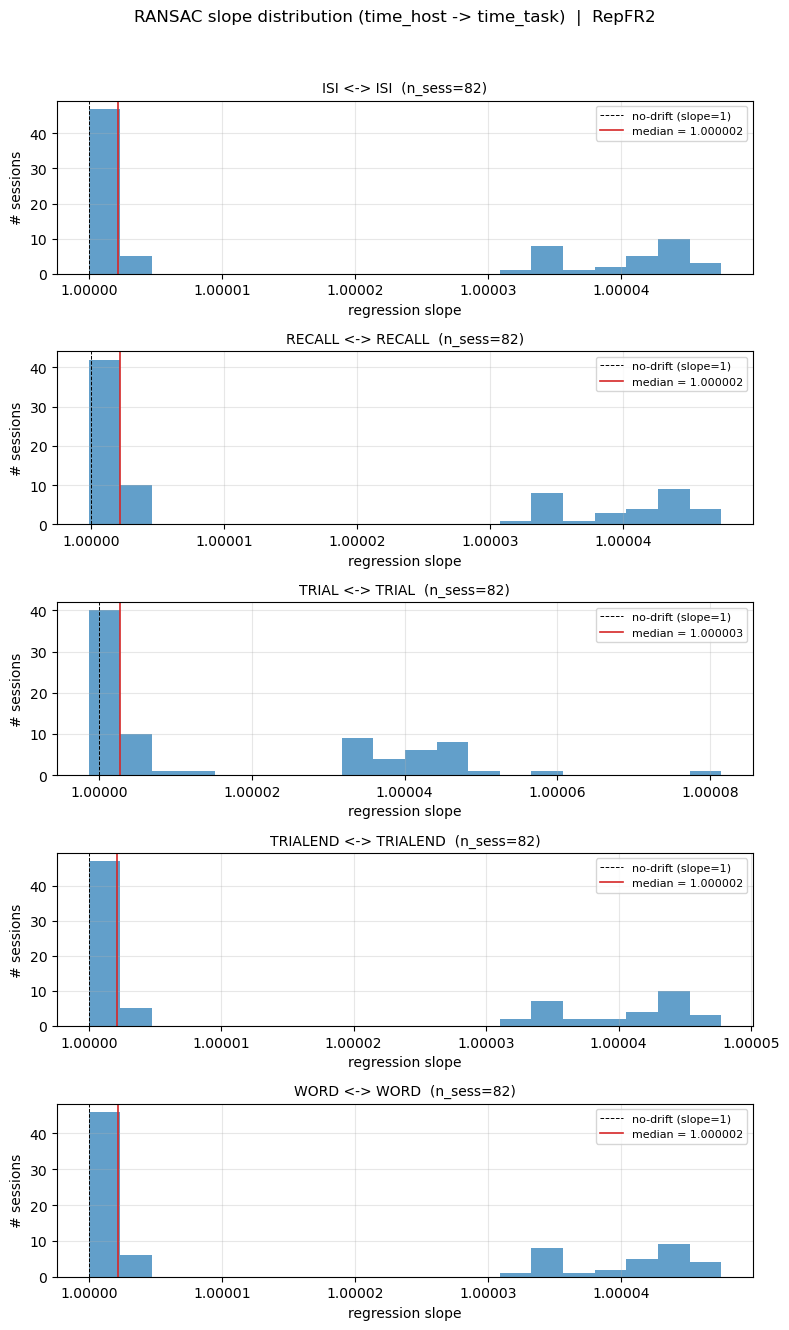

In [38]:
# Slope distribution per top candidate. Each NH candidate's fit is its own
# anchor downstream, so showing all of them is informative.
cnh.plot_slope_distribution(nh_fits, top_candidates)


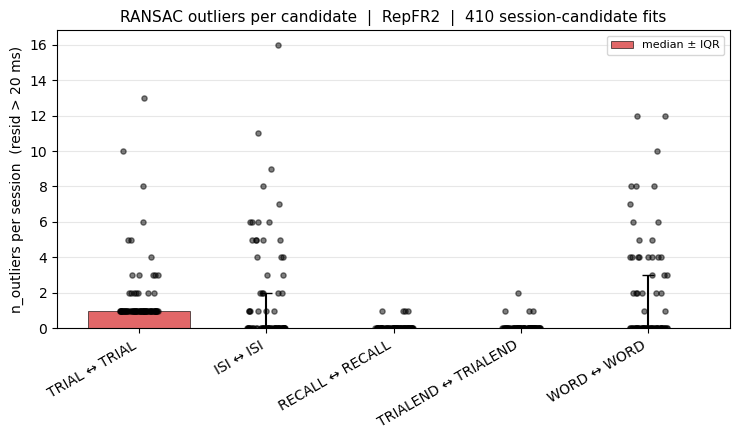

['/home1/zrentala/bids-convert/heartbeat/results/outliers_per_candidate/outliers_per_candidate_RepFR2.png']

In [39]:
# Per-candidate bar plot of RANSAC outliers (residual > RANSAC_INLIER_MS).
# Height = median n_outliers per session, IQR error bars, per-session
# values overlaid as jittered dots.
cnh.plot_outliers_per_candidate(nh_fits, top_candidates)


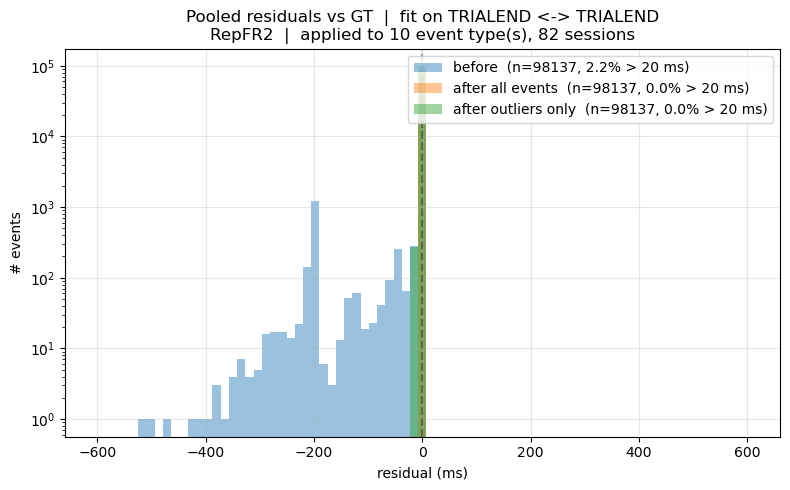

  before                : median=-0.963 ms, std=26.123 ms, p95(|x|)=1.743 ms
  after all events      : median=-0.808 ms, std=0.267 ms, p95(|x|)=1.111 ms
  after outliers only   : median=-0.943 ms, std=0.766 ms, p95(|x|)=1.629 ms



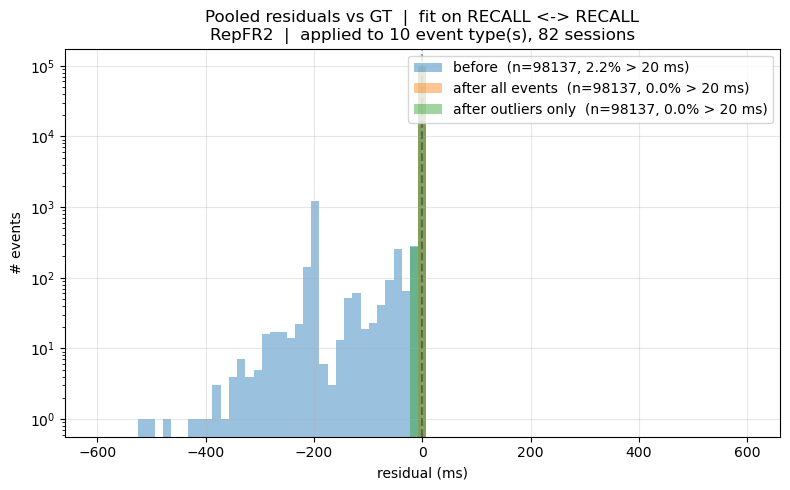

  before                : median=-0.963 ms, std=26.123 ms, p95(|x|)=1.743 ms
  after all events      : median=-1.012 ms, std=0.483 ms, p95(|x|)=1.286 ms
  after outliers only   : median=-0.953 ms, std=0.762 ms, p95(|x|)=1.630 ms



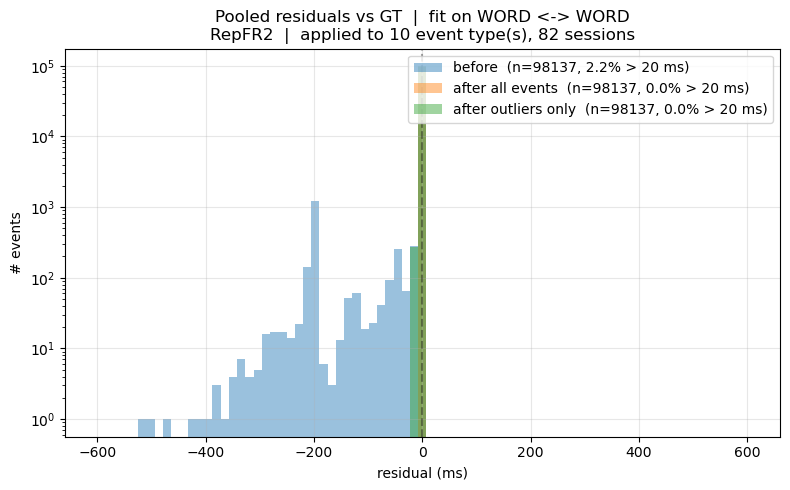

  before                : median=-0.963 ms, std=26.123 ms, p95(|x|)=1.743 ms
  after all events      : median=-1.100 ms, std=0.288 ms, p95(|x|)=1.240 ms
  after outliers only   : median=-0.955 ms, std=0.765 ms, p95(|x|)=1.628 ms



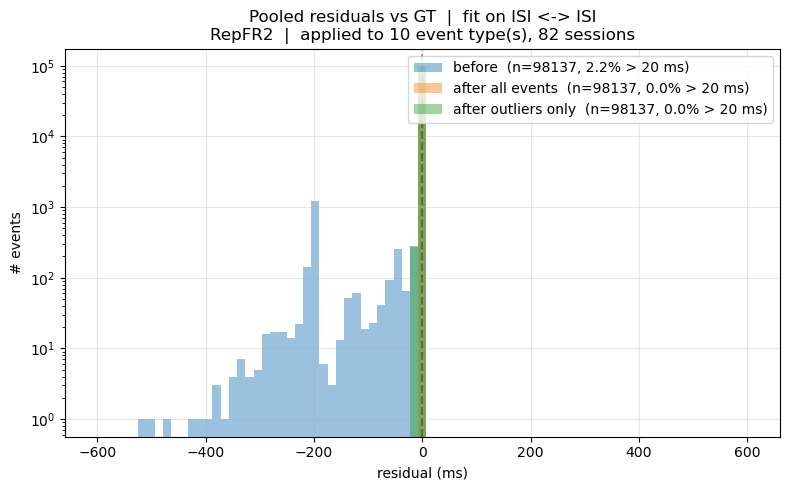

  before                : median=-0.963 ms, std=26.123 ms, p95(|x|)=1.743 ms
  after all events      : median=-1.143 ms, std=0.317 ms, p95(|x|)=1.293 ms
  after outliers only   : median=-0.955 ms, std=0.763 ms, p95(|x|)=1.628 ms



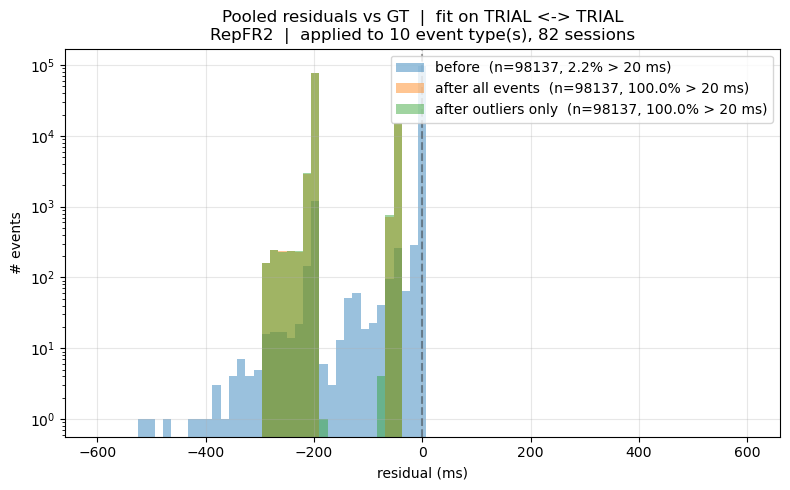

  before                : median=-0.963 ms, std=26.123 ms, p95(|x|)=1.743 ms
  after all events      : median=-201.046 ms, std=56.719 ms, p95(|x|)=204.260 ms
  after outliers only   : median=-201.033 ms, std=56.719 ms, p95(|x|)=204.319 ms



['/home1/zrentala/bids-convert/heartbeat/results/residuals_distribution_pooled/RepFR2_fit_TRIALEND_TRIALEND.png',
 '/home1/zrentala/bids-convert/heartbeat/results/residuals_distribution_pooled/RepFR2_fit_RECALL_RECALL.png',
 '/home1/zrentala/bids-convert/heartbeat/results/residuals_distribution_pooled/RepFR2_fit_WORD_WORD.png',
 '/home1/zrentala/bids-convert/heartbeat/results/residuals_distribution_pooled/RepFR2_fit_ISI_ISI.png',
 '/home1/zrentala/bids-convert/heartbeat/results/residuals_distribution_pooled/RepFR2_fit_TRIAL_TRIAL.png']

In [40]:
# Pooled residuals per candidate, three conditions overlaid:
#   before          : h - (slope_gt*t + offset_gt)            (no correction)
#   after_all       : (slope_nh*t + offset_nh) - GT line      (NH fit applied to every event)
#   after_outliers  : inliers keep h, outliers snapped to NH fit, then vs GT
cnh.plot_residuals_distribution_pooled(event_residuals, top_candidates)


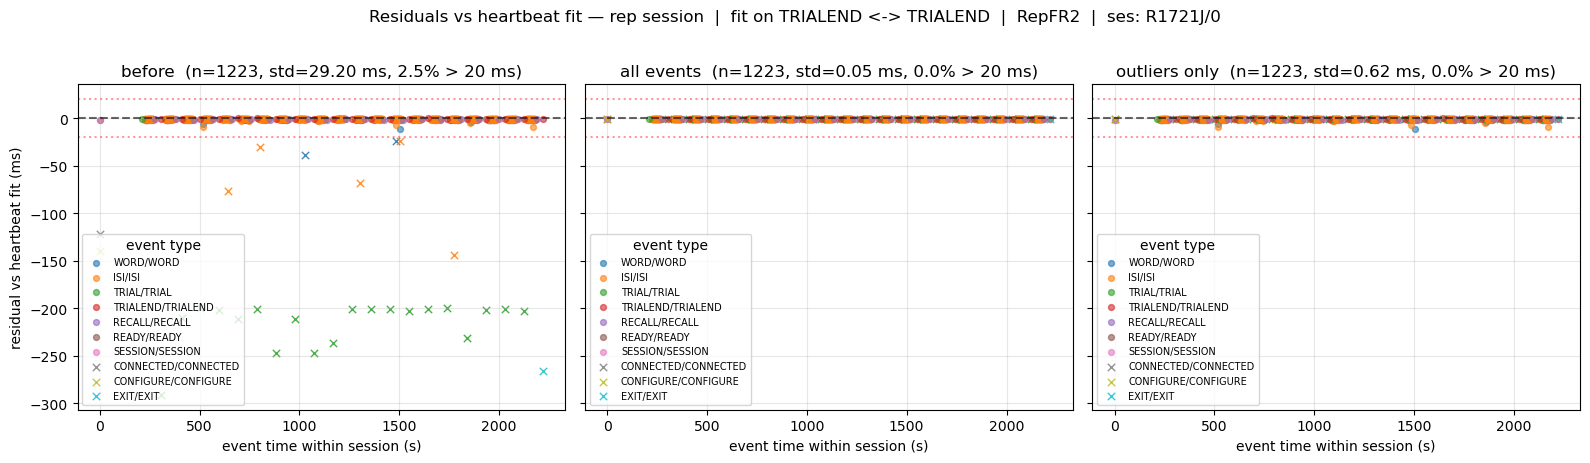

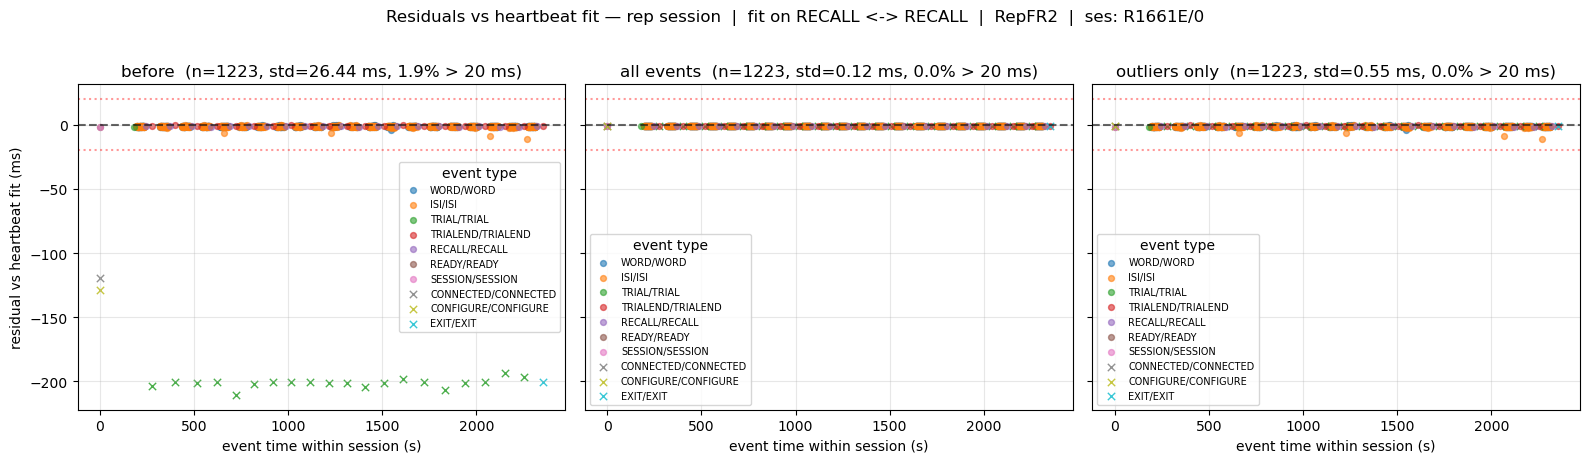

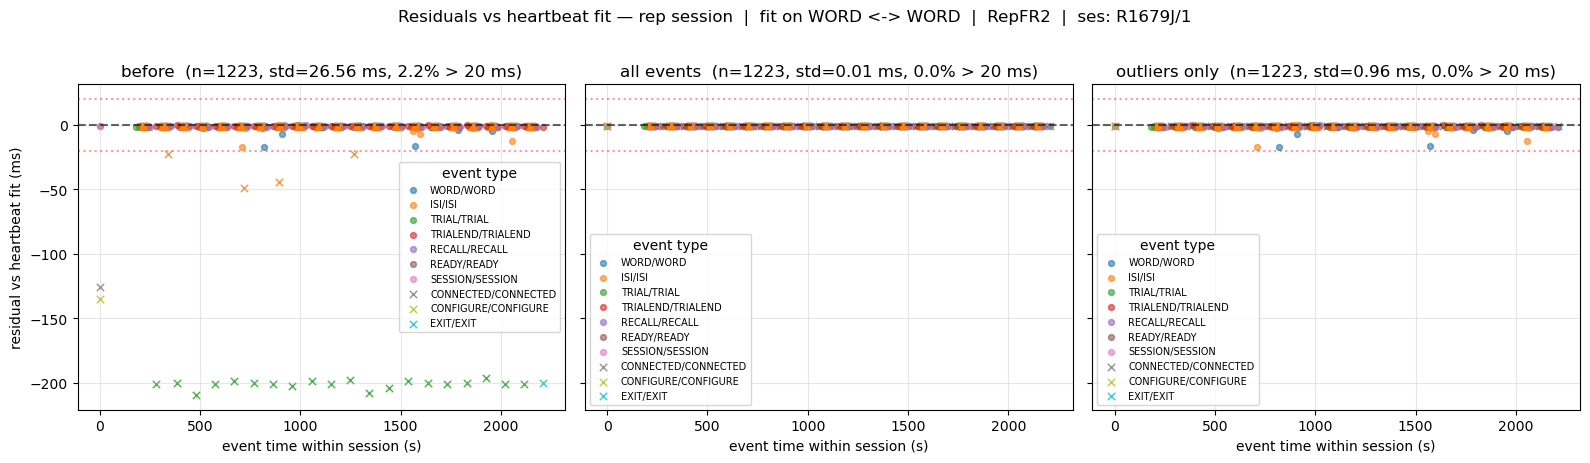

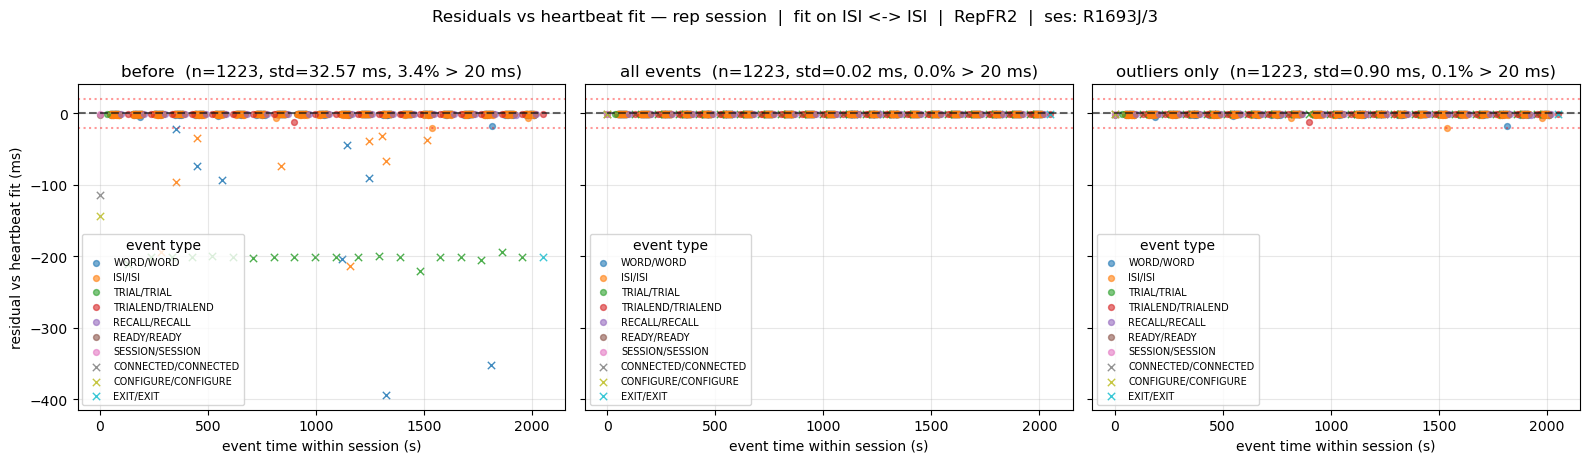

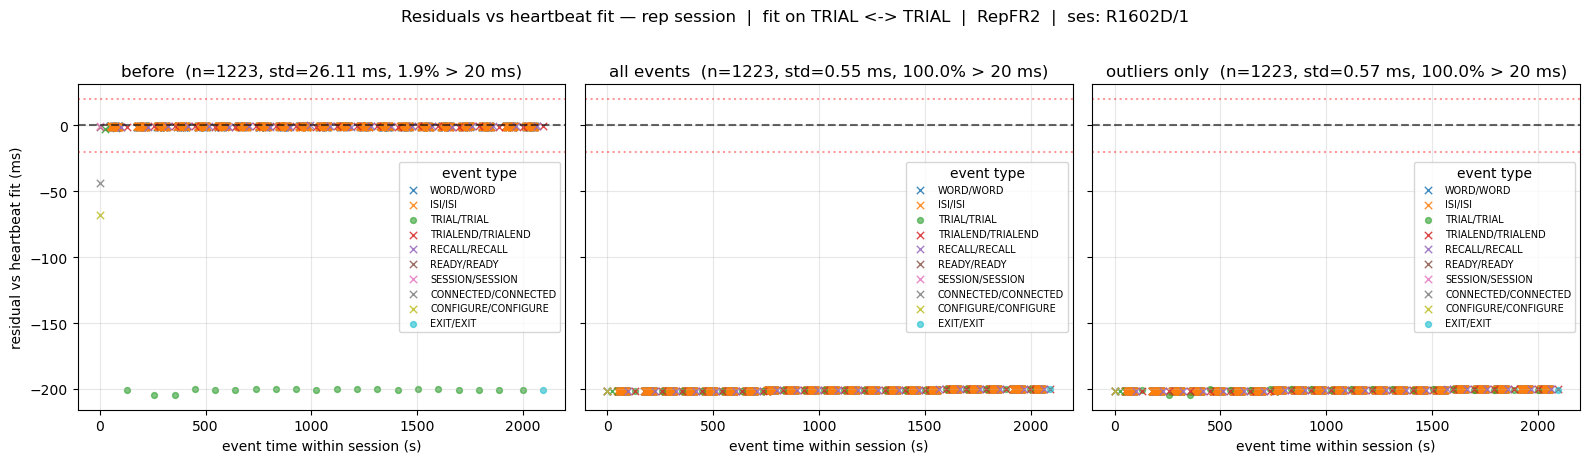

['/home1/zrentala/bids-convert/heartbeat/results/per_candidate_vs_gt/RepFR2_fit_TRIALEND_TRIALEND_R1721J_ses0.png',
 '/home1/zrentala/bids-convert/heartbeat/results/per_candidate_vs_gt/RepFR2_fit_RECALL_RECALL_R1661E_ses0.png',
 '/home1/zrentala/bids-convert/heartbeat/results/per_candidate_vs_gt/RepFR2_fit_WORD_WORD_R1679J_ses1.png',
 '/home1/zrentala/bids-convert/heartbeat/results/per_candidate_vs_gt/RepFR2_fit_ISI_ISI_R1693J_ses3.png',
 '/home1/zrentala/bids-convert/heartbeat/results/per_candidate_vs_gt/RepFR2_fit_TRIAL_TRIAL_R1602D_ses1.png']

In [41]:
# Per-candidate residuals vs GT, 2 panels (all events vs outliers only),
# using the rep session picked by median rms over the after_all condition.
cnh.plot_per_candidate_vs_gt(event_residuals, residual_summary, top_candidates)


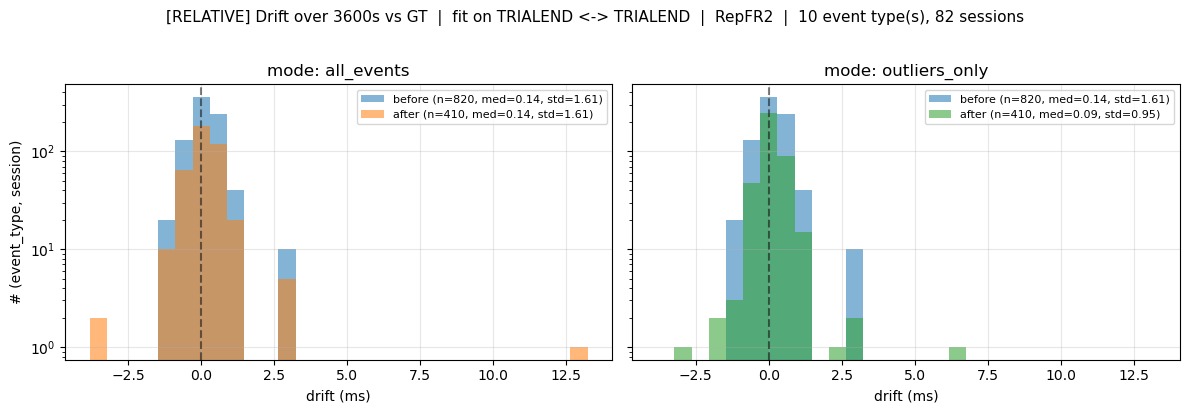

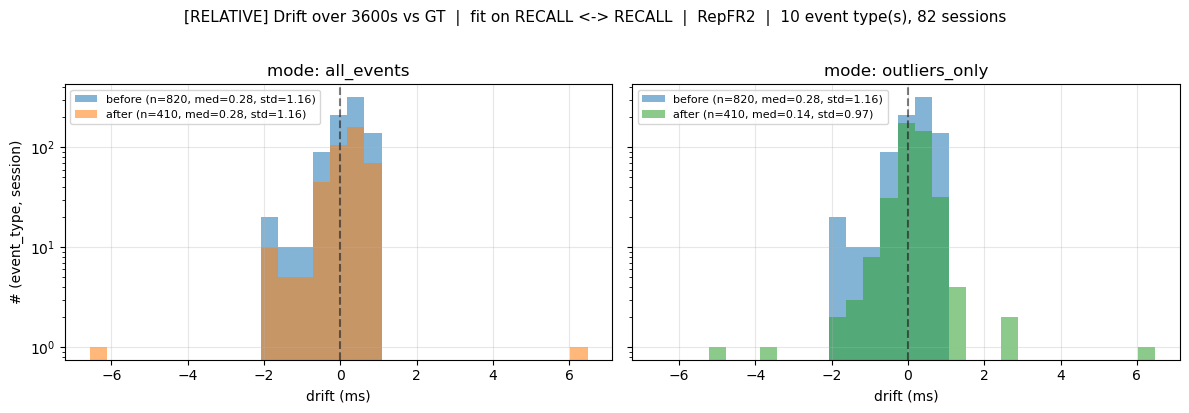

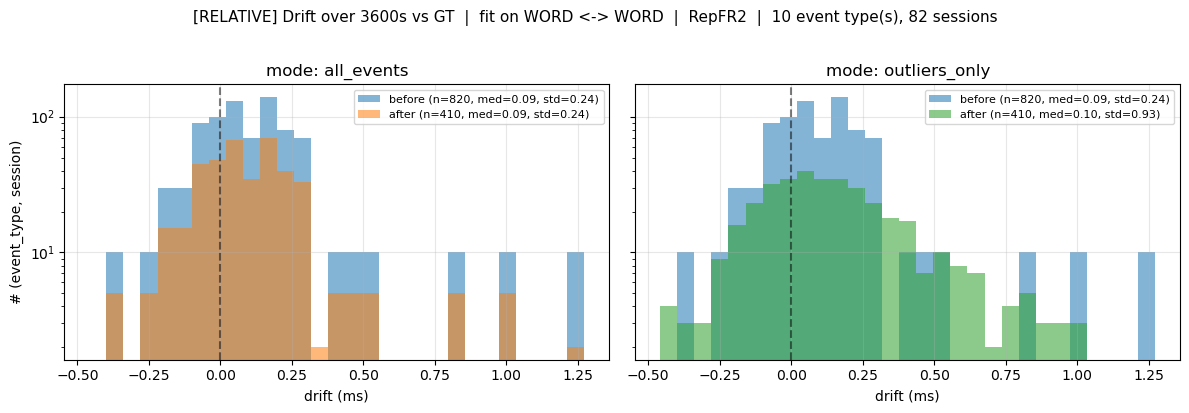

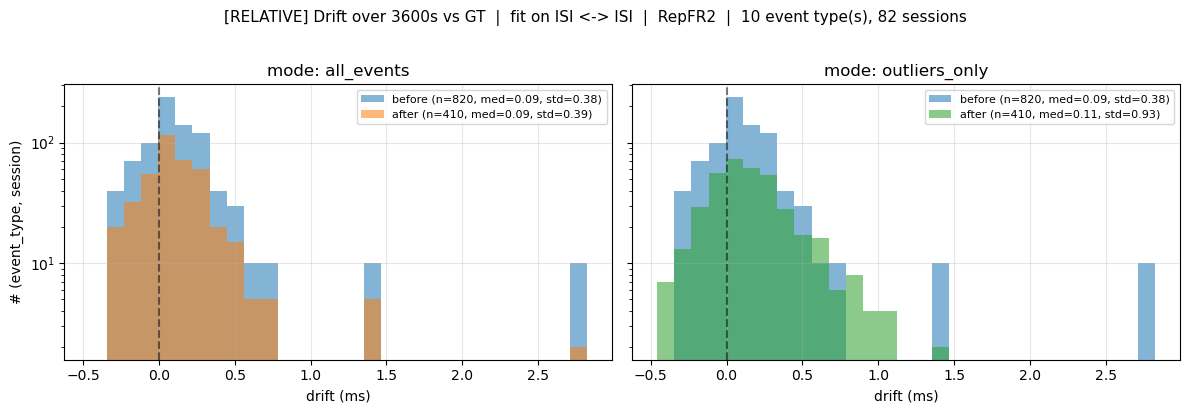

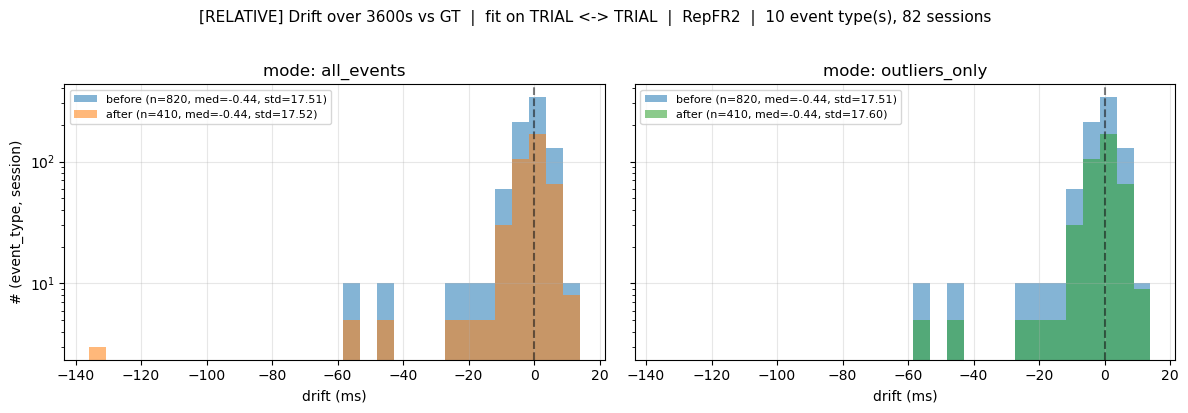

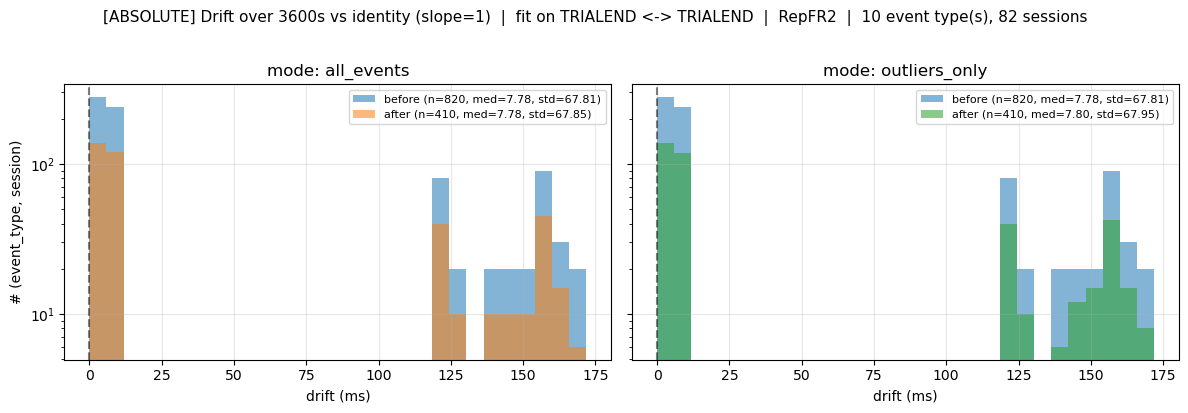

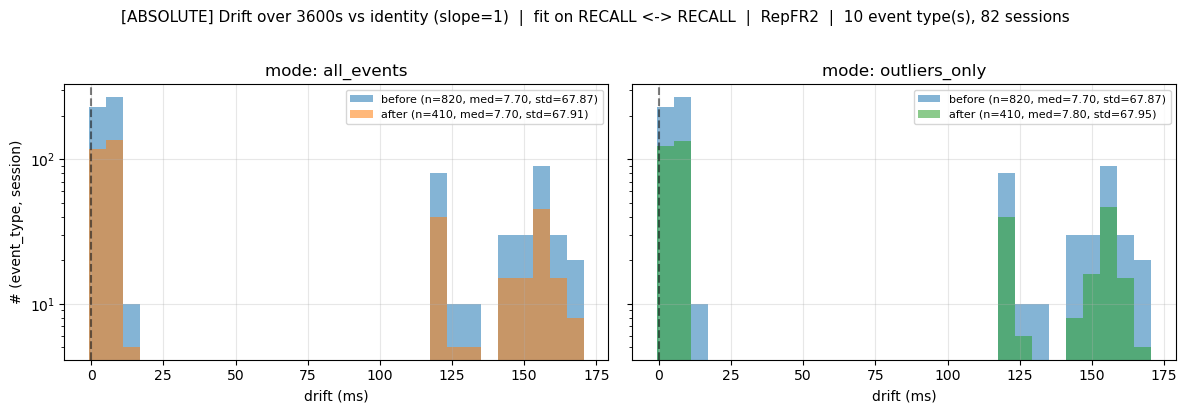

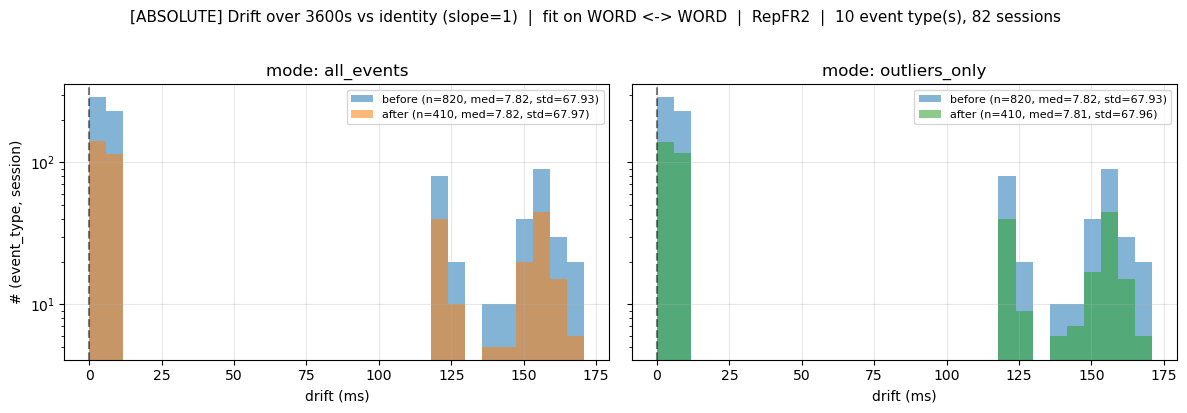

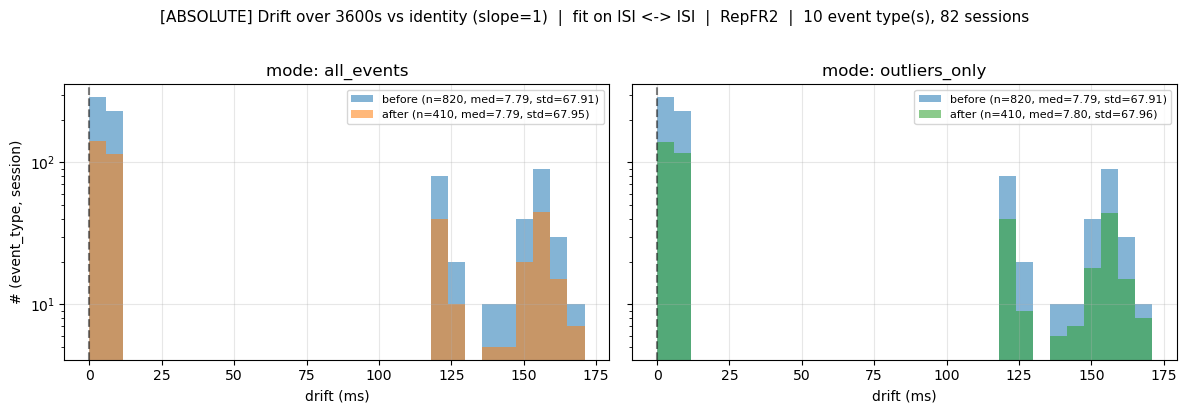

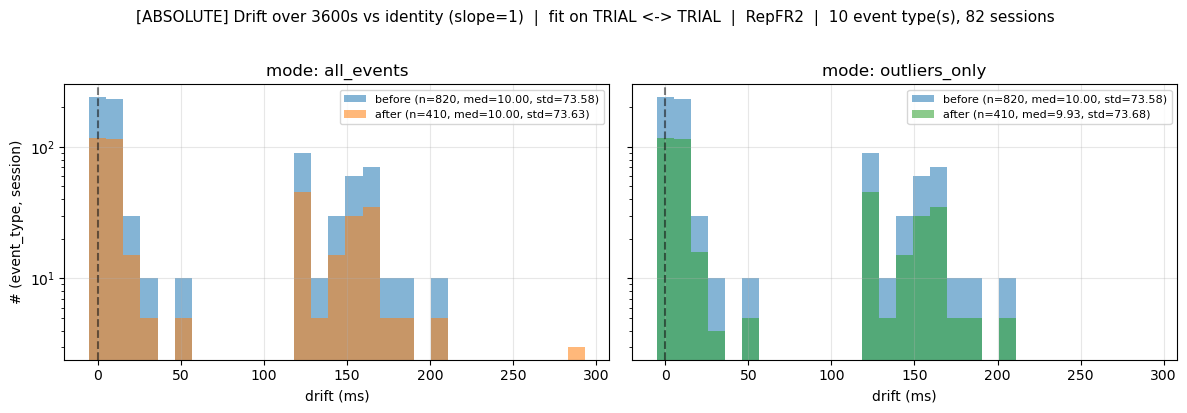

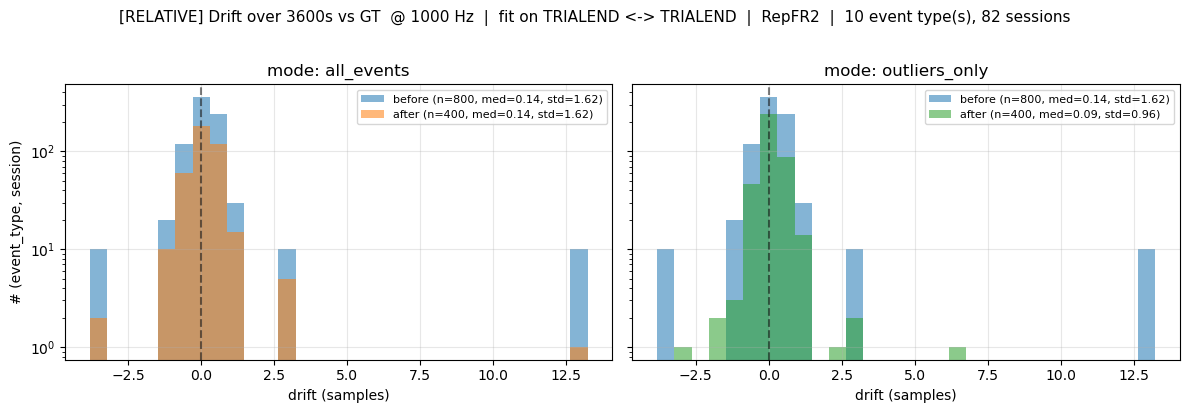

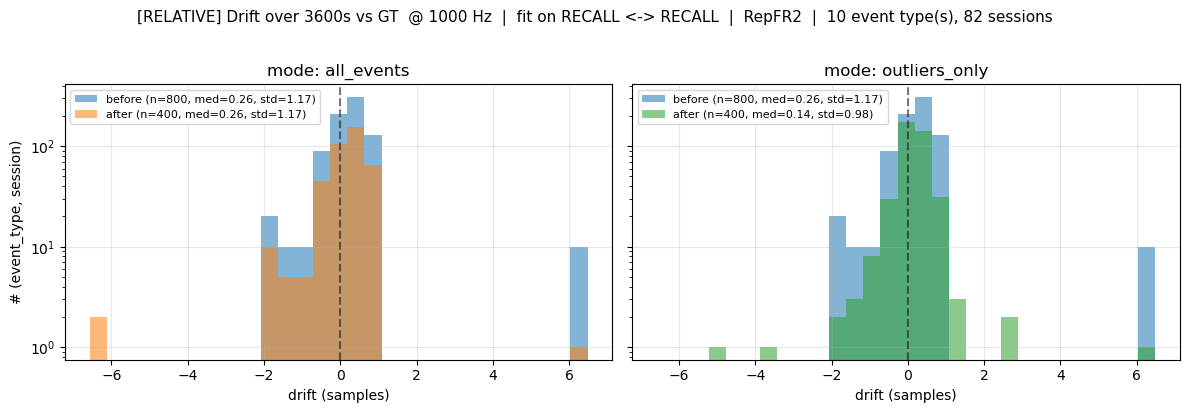

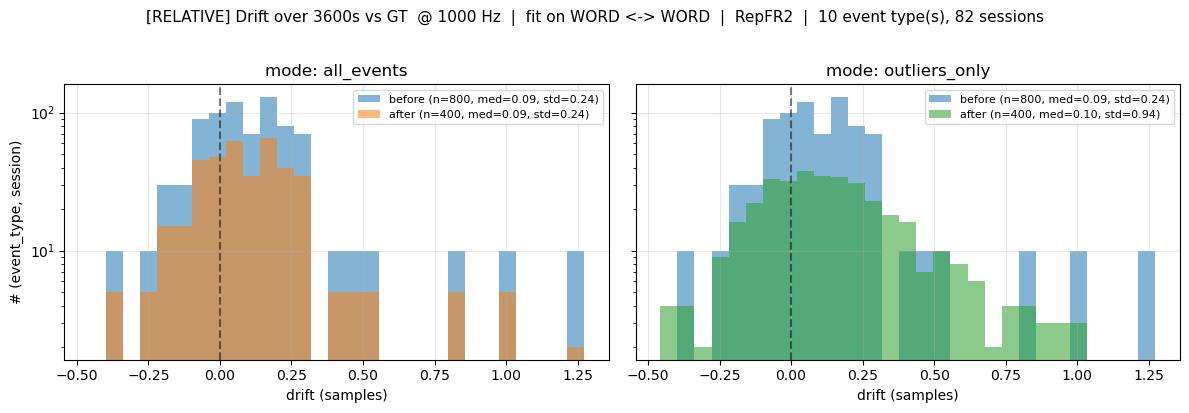

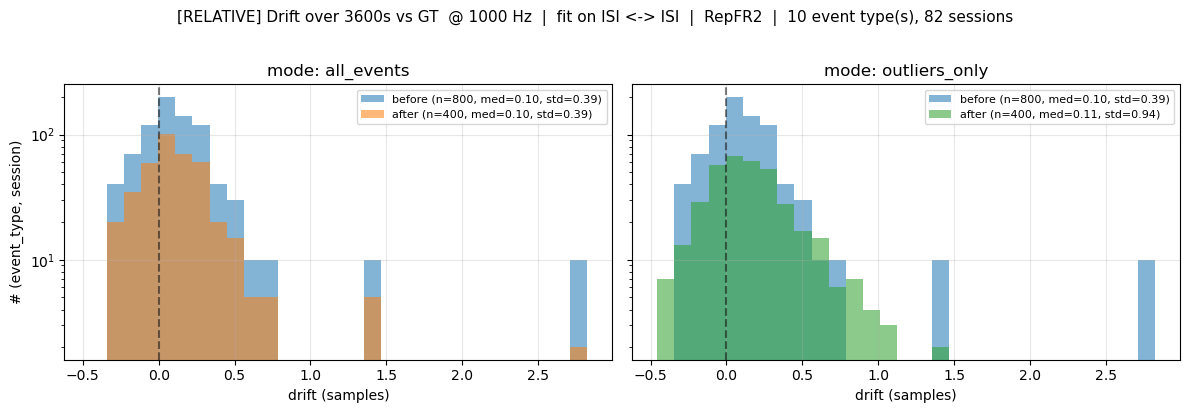

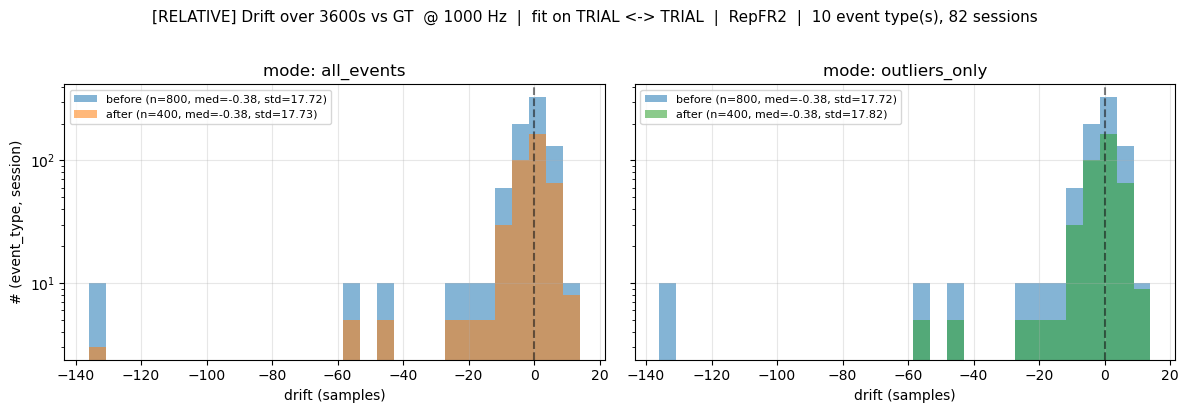

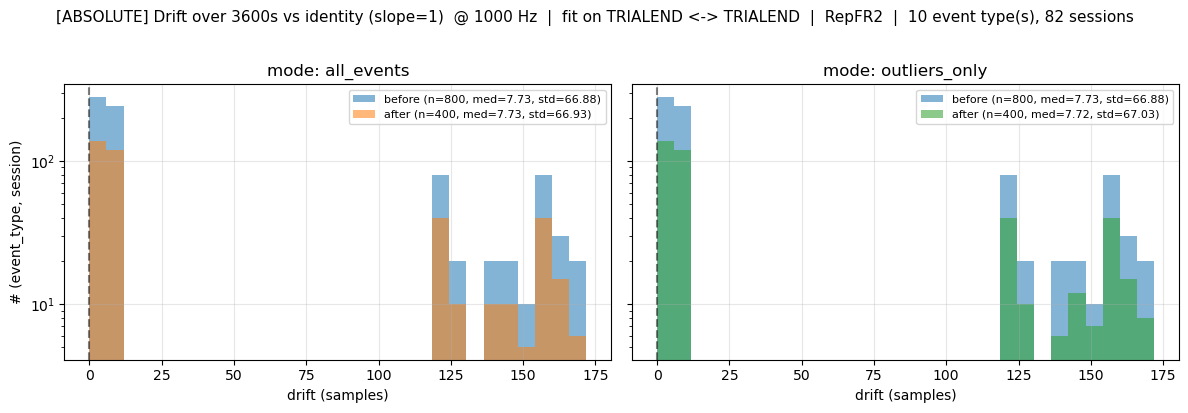

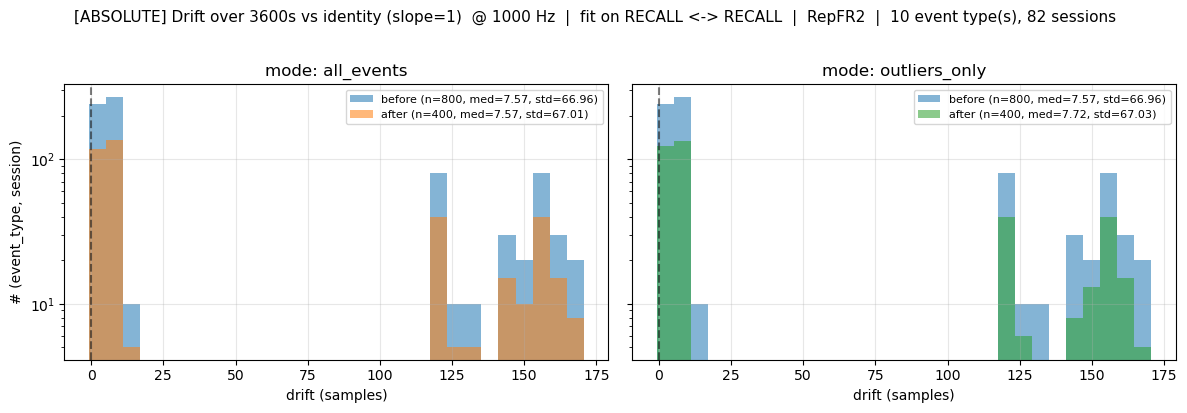

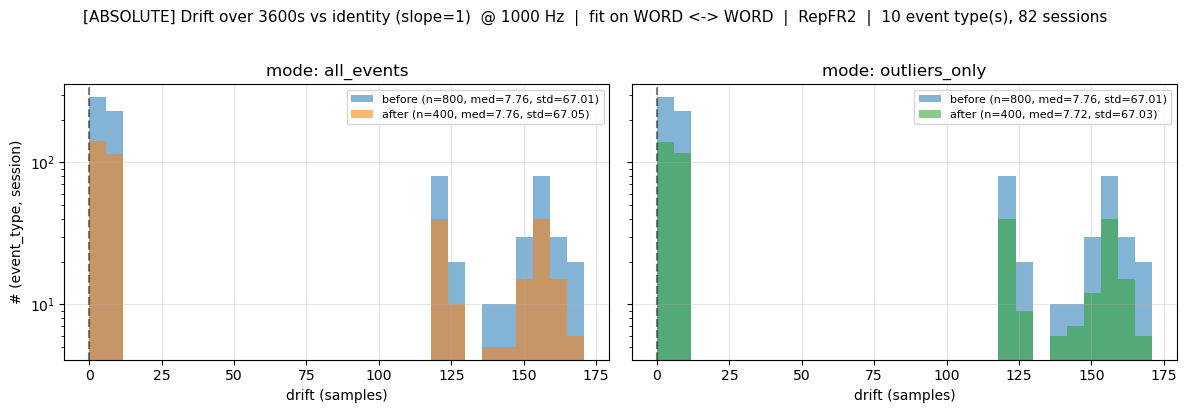

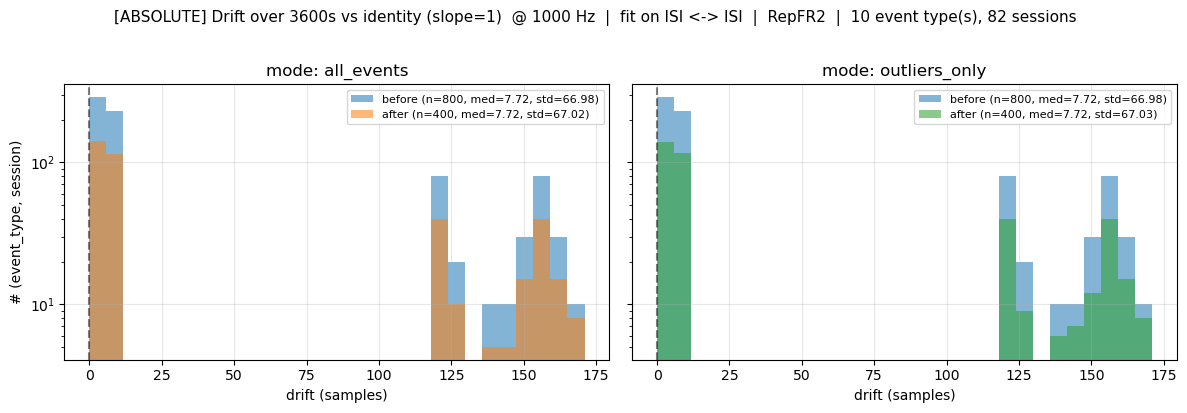

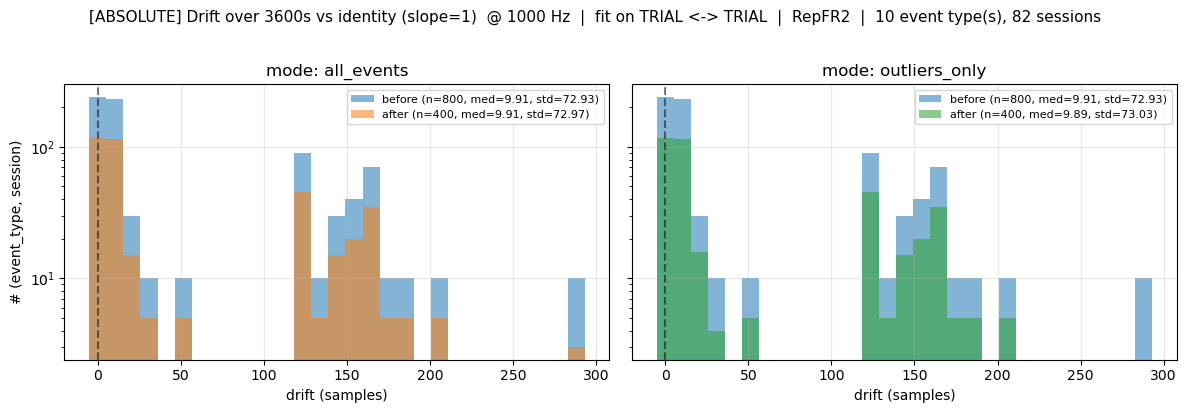

['/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_eegoffset_relative/RepFR2_fit_TRIALEND_TRIALEND_eegoffset_relative.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_eegoffset_relative/RepFR2_fit_RECALL_RECALL_eegoffset_relative.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_eegoffset_relative/RepFR2_fit_WORD_WORD_eegoffset_relative.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_eegoffset_relative/RepFR2_fit_ISI_ISI_eegoffset_relative.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_eegoffset_relative/RepFR2_fit_TRIAL_TRIAL_eegoffset_relative.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_eegoffset_absolute/RepFR2_fit_TRIALEND_TRIALEND_eegoffset_absolute.png',
 '/home1/zrentala/bids-convert/heartbeat/results/drift_distribution_eegoffset_absolute/RepFR2_fit_RECALL_RECALL_eegoffset_absolute.png',
 '/home1/zrentala/bids-convert/heartbeat/resu

In [42]:
# Drift distribution: one figure per candidate, 2 panels by mode
# (all_events, outliers_only). Each panel overlays before vs after.
cnh.plot_drift_distribution(drift_df, top_candidates, kind='wallclock')
cnh.plot_drift_distribution(drift_df, top_candidates, kind='eegoffset')


# Compare modes — aggregated across sessions

Top-10 candidates per experiment compared mode-vs-mode. **Blue = `all_events`, orange = `outliers_only`.** Per-session RMS and residual mean/std are paired on `(subject, session)` between the two modes and compared with the paired Wilcoxon signed-rank test (significance stars: `*` p<.05, `**` p<.01, `***` p<.001, `ns` otherwise).

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/usr/global/miniconda/py

,experiment,fit_task_type,fit_host_type,task_type,host_type,mode_a,mode_b,n_paired,mode_a_mean,mode_b_mean,statistic,pvalue
0,RepFR2,TRIALEND,TRIALEND,WORD,WORD,before,all_events,82,4.751752,0.807676,0.0,3.663891e-15
1,RepFR2,TRIALEND,TRIALEND,WORD,WORD,before,outliers_only,82,4.751752,1.141679,0.0,1.734398e-06
2,RepFR2,TRIALEND,TRIALEND,WORD,WORD,all_events,outliers_only,82,0.807676,1.141679,9.0,5.104265e-15
3,RepFR2,RECALL,RECALL,WORD,WORD,before,all_events,82,4.751752,0.991958,81.0,6.810943e-14
4,RepFR2,RECALL,RECALL,WORD,WORD,before,outliers_only,82,4.751752,1.138876,0.0,1.734398e-06
...,...,...,...,...,...,...,...,...,...,...,...,...
145,RepFR2,ISI,ISI,EXIT,EXIT,before,outliers_only,79,182.815091,1.056777,0.0,1.149056e-14
146,RepFR2,ISI,ISI,EXIT,EXIT,all_events,outliers_only,79,1.056777,1.056777,NaN,NaN
147,RepFR2,TRIAL,TRIAL,EXIT,EXIT,before,all_events,79,182.815091,178.191619,1247.0,1.036534e-01
148,RepFR2,TRIAL,TRIAL,EXIT,EXIT,before,outliers_only,79,182.815091,178.608879,1.0,4.639946e-02


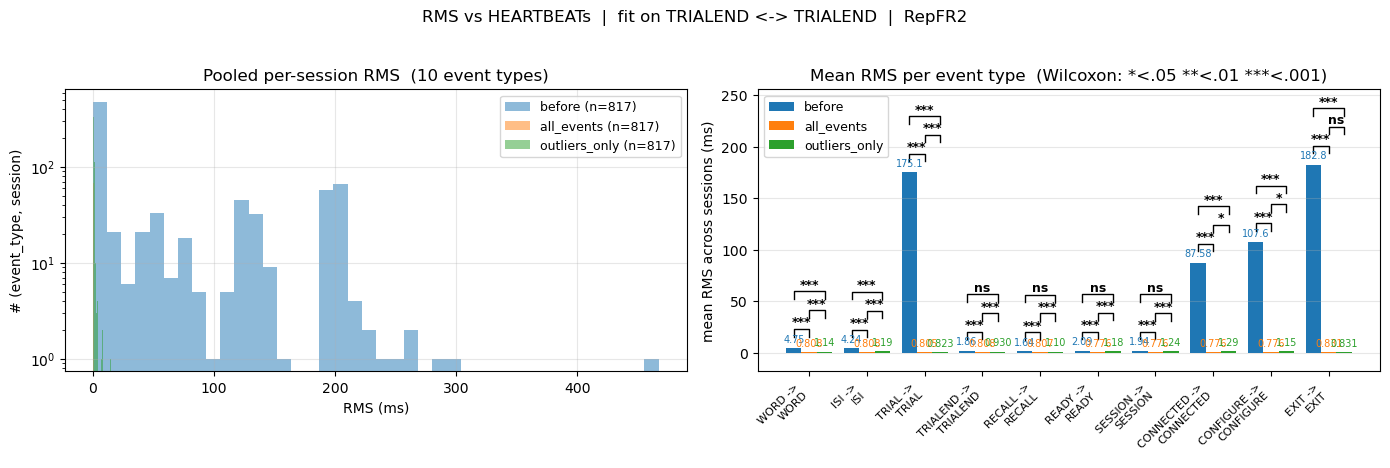

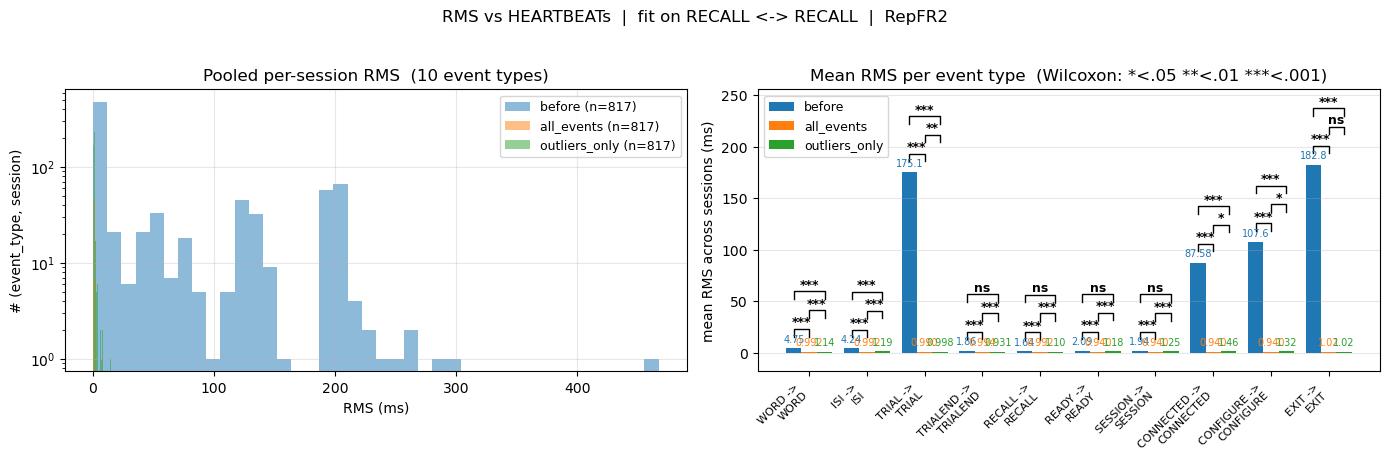

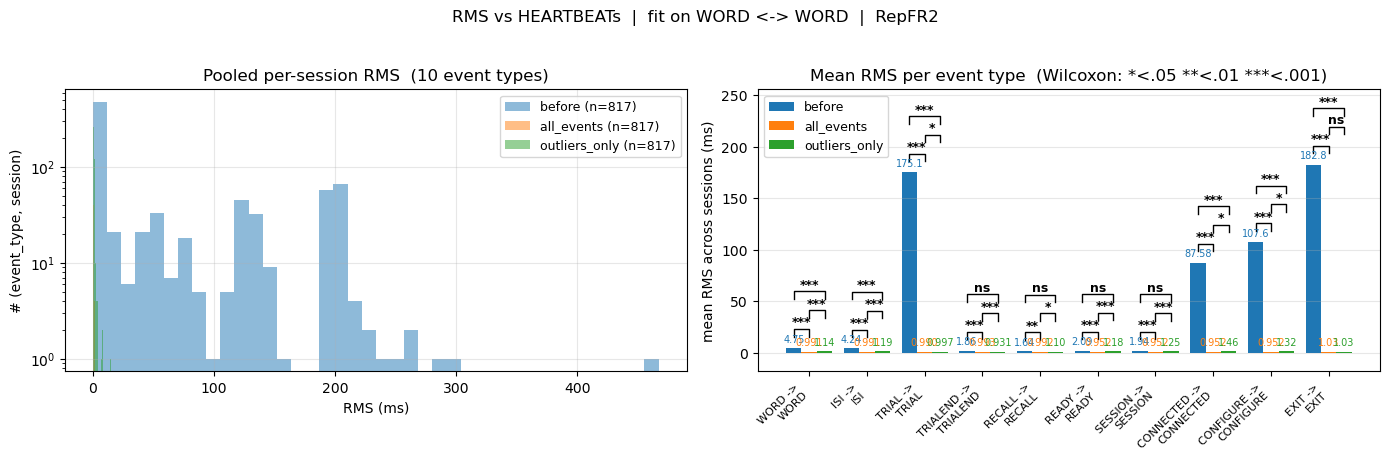

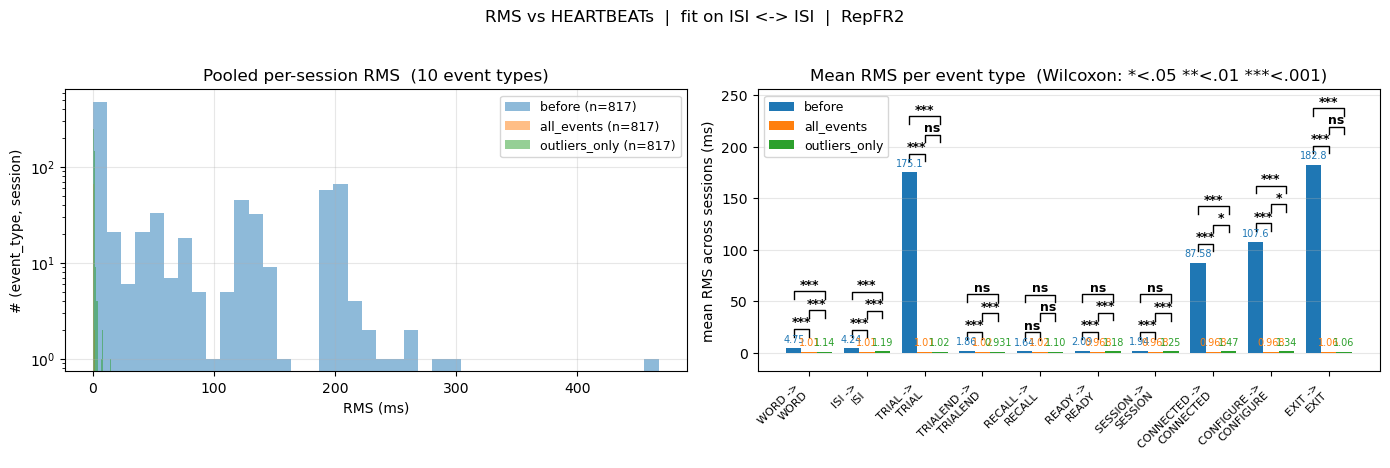

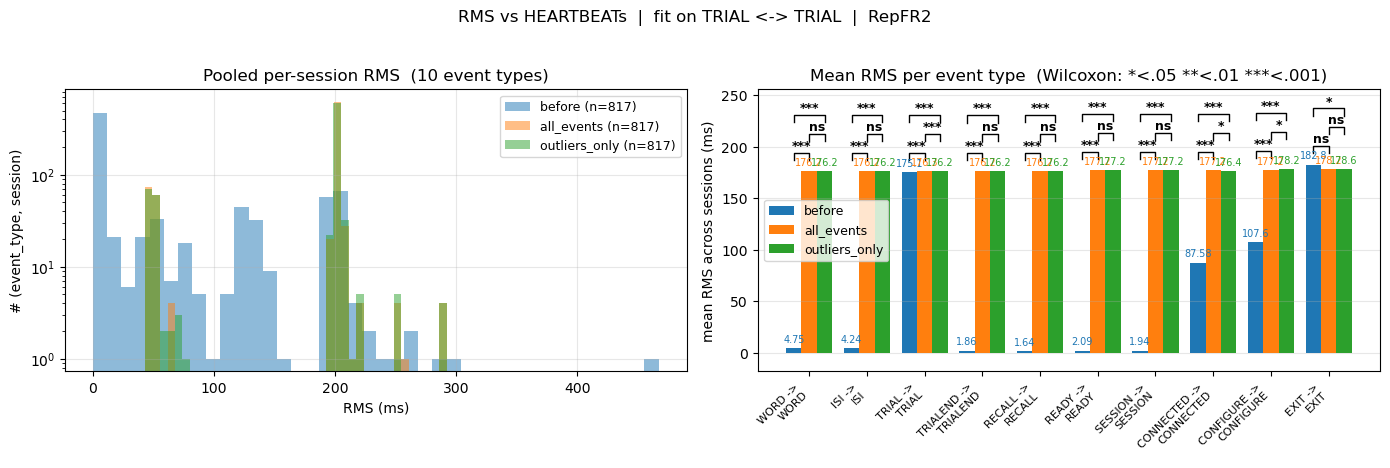

['/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR2_fit_TRIALEND_TRIALEND_rms.png',
 '/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR2_fit_RECALL_RECALL_rms.png',
 '/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR2_fit_WORD_WORD_rms.png',
 '/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR2_fit_ISI_ISI_rms.png',
 '/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR2_fit_TRIAL_TRIAL_rms.png']

In [43]:
# RMS comparison: per-session RMS hist + per-candidate mean RMS bars with
# paired Wilcoxon between ALL pairs of modes (before, all_events, outliers_only).
# Reads only `residual_summary` + `top_candidates`.
thresh = 50

# Filter candidates: drop those whose all_events RMS mean exceeds `thresh`.
# (Low-session candidates like COUNTDOWN/REST are already excluded upstream
# by filter_unambiguous(min_session_frac=0.5).)
cand_rms = (residual_summary
            .query("condition == 'after_all'")
            .groupby(['experiment', 'task_type', 'host_type'])['rms']
            .mean())
plot_cands = (cand_rms[cand_rms < thresh]
              .reset_index()
              [['experiment', 'task_type', 'host_type']])

wilcoxon_rms = cnh.paired_wilcoxon_all_pairs(residual_summary, stat_col='rms')
display(wilcoxon_rms.merge(plot_cands, on=['experiment', 'task_type', 'host_type']))
cnh.plot_rms_comparison(residual_summary, plot_cands, wilcoxon_rms)


/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/usr/global/miniconda/py

,experiment,fit_task_type,fit_host_type,task_type,host_type,mode_a,mode_b,n_paired,mode_a_mean,mode_b_mean,statistic,pvalue
0,RepFR2,TRIALEND,TRIALEND,WORD,WORD,before,all_events,82,-1.348657,-0.798435,8.0,4.920065e-15
1,RepFR2,TRIALEND,TRIALEND,WORD,WORD,before,outliers_only,82,-1.348657,-0.989476,0.0,1.734398e-06
2,RepFR2,TRIALEND,TRIALEND,WORD,WORD,all_events,outliers_only,82,-0.798435,-0.989476,164.0,1.179408e-12
3,RepFR2,RECALL,RECALL,WORD,WORD,before,all_events,82,-1.348657,-0.983290,417.0,2.882413e-09
4,RepFR2,RECALL,RECALL,WORD,WORD,before,outliers_only,82,-1.348657,-0.989602,0.0,1.734398e-06
...,...,...,...,...,...,...,...,...,...,...,...,...
145,RepFR2,ISI,ISI,EXIT,EXIT,before,outliers_only,79,-182.815091,-1.056777,0.0,1.149056e-14
146,RepFR2,ISI,ISI,EXIT,EXIT,all_events,outliers_only,79,-1.056777,-1.056777,NaN,NaN
147,RepFR2,TRIAL,TRIAL,EXIT,EXIT,before,all_events,79,-182.815091,-178.191619,1247.0,1.036534e-01
148,RepFR2,TRIAL,TRIAL,EXIT,EXIT,before,outliers_only,79,-182.815091,-178.608879,1.0,4.639946e-02


,experiment,fit_task_type,fit_host_type,task_type,host_type,mode_a,mode_b,n_paired,mode_a_mean,mode_b_mean,statistic,pvalue
0,RepFR2,TRIALEND,TRIALEND,WORD,WORD,before,all_events,82,4.278327,0.082517,7.0,4.742412e-15
1,RepFR2,TRIALEND,TRIALEND,WORD,WORD,before,outliers_only,82,4.278327,0.526133,0.0,1.734398e-06
2,RepFR2,TRIALEND,TRIALEND,WORD,WORD,all_events,outliers_only,82,0.082517,0.526133,10.0,5.295250e-15
3,RepFR2,RECALL,RECALL,WORD,WORD,before,all_events,82,4.278327,0.091353,0.0,3.663891e-15
4,RepFR2,RECALL,RECALL,WORD,WORD,before,outliers_only,82,4.278327,0.521763,0.0,1.734398e-06
...,...,...,...,...,...,...,...,...,...,...,...,...
145,RepFR2,ISI,ISI,EXIT,EXIT,before,outliers_only,79,0.000000,0.000000,NaN,NaN
146,RepFR2,ISI,ISI,EXIT,EXIT,all_events,outliers_only,79,0.000000,0.000000,NaN,NaN
147,RepFR2,TRIAL,TRIAL,EXIT,EXIT,before,all_events,79,0.000000,0.000000,NaN,NaN
148,RepFR2,TRIAL,TRIAL,EXIT,EXIT,before,outliers_only,79,0.000000,0.000000,NaN,NaN


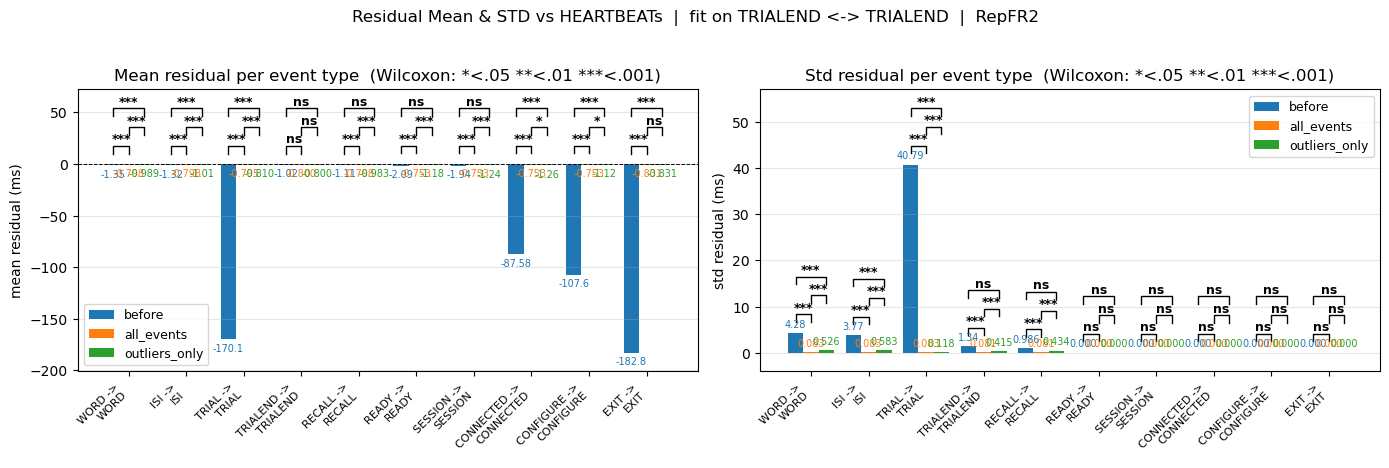

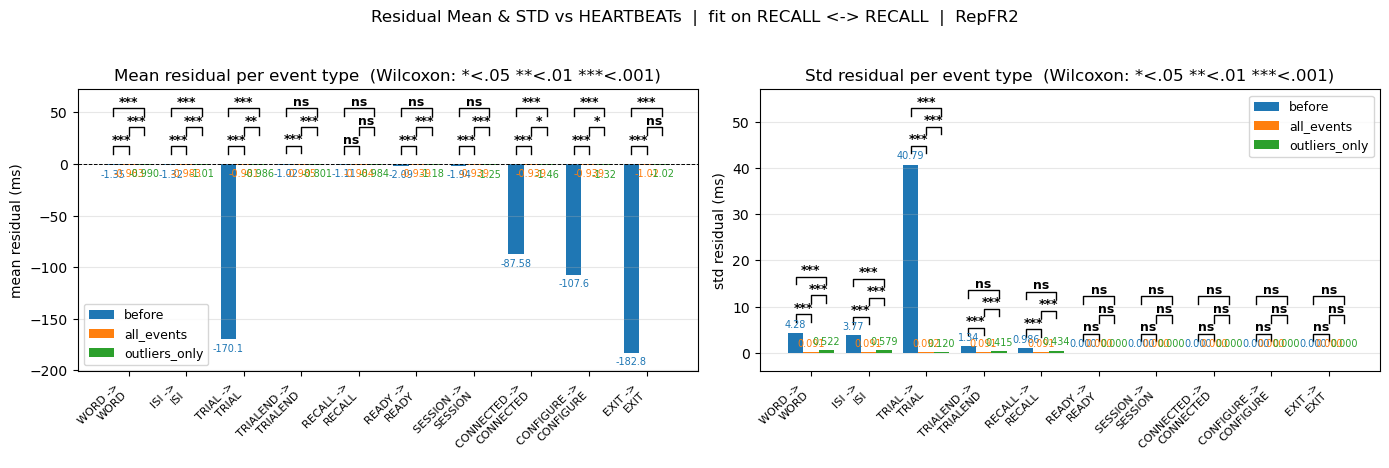

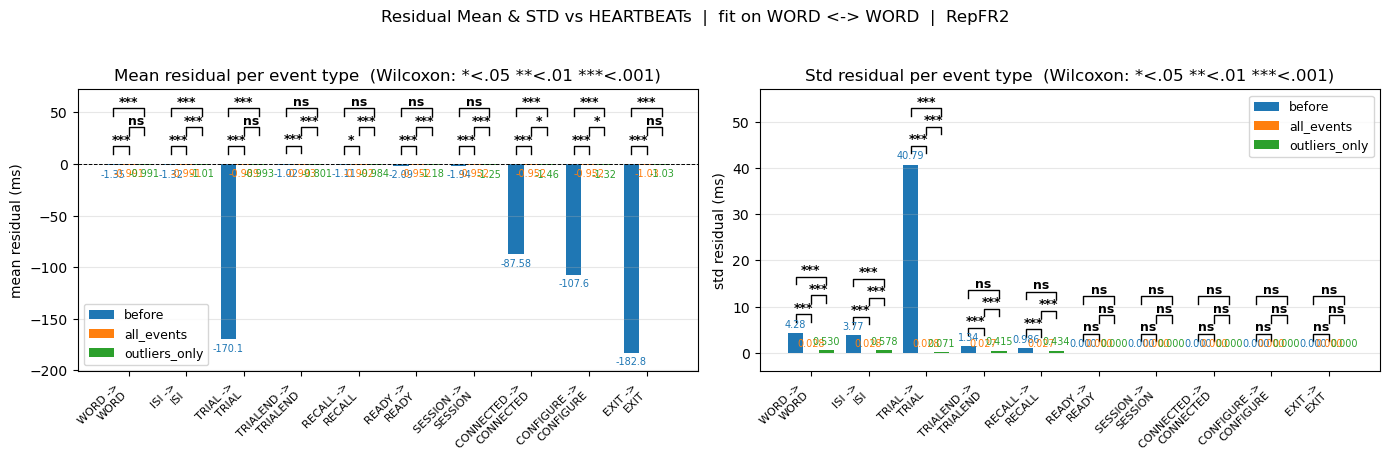

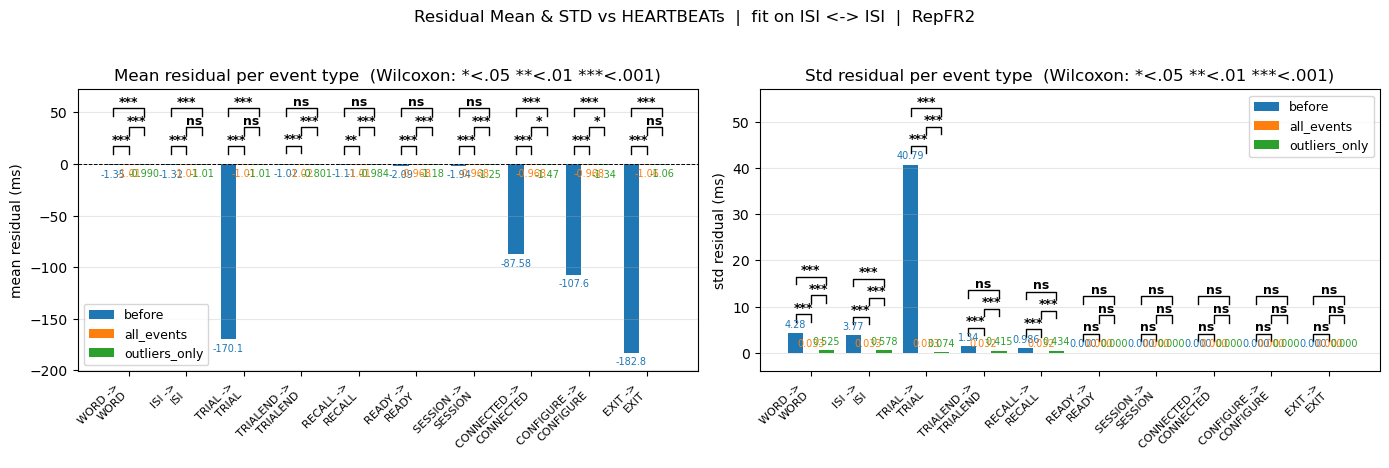

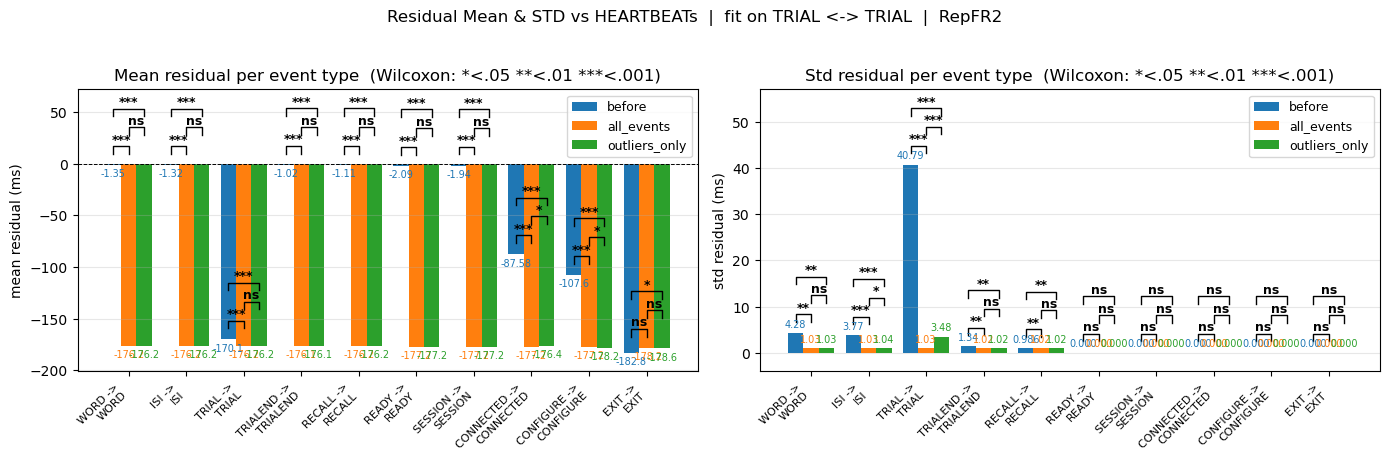

['/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR2_fit_TRIALEND_TRIALEND_mean_std.png',
 '/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR2_fit_RECALL_RECALL_mean_std.png',
 '/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR2_fit_WORD_WORD_mean_std.png',
 '/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR2_fit_ISI_ISI_mean_std.png',
 '/home1/zrentala/bids-convert/heartbeat/results/mode_comparison/RepFR2_fit_TRIAL_TRIAL_mean_std.png']

In [44]:
# Residual mean & std comparison: two-panel bar chart per experiment,
# paired Wilcoxon between ALL pairs of modes on per-session mean / std residual.
wilcoxon_mean = cnh.paired_wilcoxon_all_pairs(residual_summary, stat_col='mean_resid')
wilcoxon_std  = cnh.paired_wilcoxon_all_pairs(residual_summary, stat_col='std_resid')
display(wilcoxon_mean.merge(plot_cands, on=['experiment', 'task_type', 'host_type']))
display(wilcoxon_std .merge(plot_cands, on=['experiment', 'task_type', 'host_type']))
cnh.plot_residual_mean_std_comparison(residual_summary, plot_cands,
                                      wilcoxon_mean, wilcoxon_std)
